In [5]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

# =========================
# Local Jupyter setting
# =========================

DATA_PATH = "UCI_Credit_Card.csv"

OUTPUT_DIR = Path("outputs")
FIG_DIR = OUTPUT_DIR / "eda_figures"

OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Helper functions
# =========================

def save_fig(filename):
    path = FIG_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved figure: {path}")

def clean_filename(text):
    text = re.sub(r"[^\w\s-]", "", text)
    text = re.sub(r"\s+", "_", text.strip())
    return text.lower()

def add_bar_labels(ax, fmt="{:.1f}"):
    for p in ax.patches:
        height = p.get_height()
        if pd.notna(height):
            ax.annotate(
                fmt.format(height),
                (p.get_x() + p.get_width() / 2, height),
                ha="center",
                va="bottom",
                fontsize=9
            )

# =========================
# Load data
# =========================

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())
df.info()

Dataset loaded successfully.
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Global plotting style
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.labelsize"] = 13
plt.rcParams["ytick.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["font.family"] = "DejaVu Sans"   # 默认比较稳

In [7]:
target_col = "default.payment.next.month"

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
missing_table = df.isnull().sum().to_frame("missing_count")
display(missing_table)

print("\nDuplicated rows:", df.duplicated().sum())

print("\nTarget distribution:")
target_count = df[target_col].value_counts().sort_index().to_frame("count")
display(target_count)

print("\nTarget distribution percentage:")
target_pct = (df[target_col].value_counts(normalize=True).sort_index() * 100).round(2).to_frame("percentage")
display(target_pct)

# Save basic tables
missing_table.to_csv(OUTPUT_DIR / "missing_values.csv")
target_count.to_csv(OUTPUT_DIR / "target_distribution_count.csv")
target_pct.to_csv(OUTPUT_DIR / "target_distribution_percentage.csv")

Dataset shape: (30000, 25)

Columns:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']

Missing values:


,missing_count
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0



Duplicated rows: 0

Target distribution:


,count
default.payment.next.month,
0,23364
1,6636



Target distribution percentage:


,percentage
default.payment.next.month,
0,77.88
1,22.12


In [9]:
df_eda = df.copy()

# Rename target for convenience
df_eda = df_eda.rename(columns={target_col: "DEFAULT"})
target = "DEFAULT"

# Variable groups
pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
demo_cols = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE"]

# Label mapping for EDA only
df_eda["SEX_LABEL"] = df_eda["SEX"].map({
    1: "Male",
    2: "Female"
})

df_eda["EDUCATION_LABEL"] = df_eda["EDUCATION"].map({
    0: "Unknown/Others",
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Others",
    5: "Unknown/Others",
    6: "Unknown/Others"
})

df_eda["MARRIAGE_LABEL"] = df_eda["MARRIAGE"].map({
    0: "Unknown/Others",
    1: "Married",
    2: "Single",
    3: "Others"
})

print("Target column:", target)
print("Demographic columns:", demo_cols)
print("Repayment status columns:", pay_status_cols)
print("Bill amount columns:", bill_cols)
print("Payment amount columns:", pay_amt_cols)

display(df_eda.head())

Target column: DEFAULT
Demographic columns: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE']
Repayment status columns: ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Bill amount columns: ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
Payment amount columns: ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT,SEX_LABEL,EDUCATION_LABEL,MARRIAGE_LABEL
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,Female,University,Married
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,Female,University,Single
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,Female,University,Single
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,Female,University,Married
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,Male,University,Married


Saved figure: outputs\eda_figures\01_target_distribution_refined.png


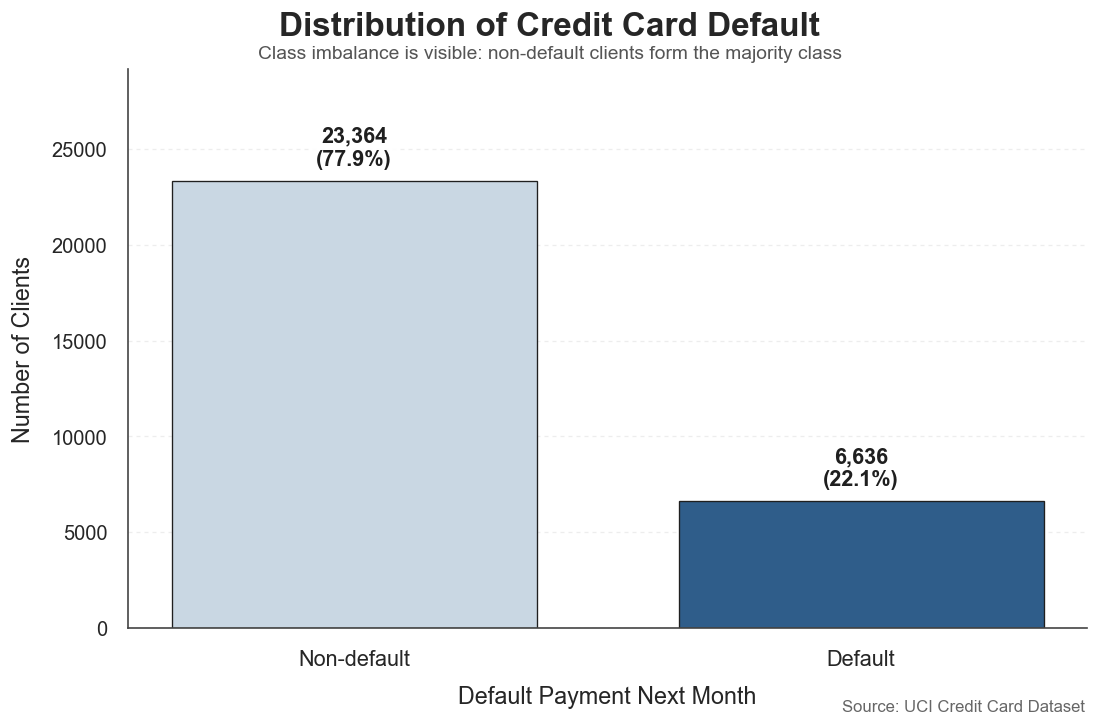

In [23]:
# Cell 4: Refined publication-style target distribution plot

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------- Data for plotting -------
plot_df = df_eda[target].value_counts().sort_index().reset_index()
plot_df.columns = ["DEFAULT", "Count"]
plot_df["Class"] = ["Non-default", "Default"]
plot_df["Percentage"] = plot_df["Count"] / plot_df["Count"].sum() * 100

# ------- Style -------
sns.set_theme(style="white", context="talk")

fig, ax = plt.subplots(figsize=(9.5, 6.4), facecolor="white")

# Leave more space at the top and bottom
fig.subplots_adjust(top=0.84, bottom=0.14, left=0.10, right=0.97)

# Refined palette
colors = ["#C9D7E3", "#2F5D8A"]

bars = ax.bar(
    plot_df["Class"],
    plot_df["Count"],
    color=colors,
    width=0.72,
    edgecolor="#1F1F1F",
    linewidth=0.8
)

# ------- Grid and axes -------
ax.yaxis.grid(True, linestyle=(0, (3, 3)), linewidth=0.8, alpha=0.35)
ax.xaxis.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)
ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")

# ------- Title and subtitle -------
fig.suptitle(
    "Distribution of Credit Card Default",
    fontsize=20,
    fontweight="bold",
    y=0.95
)

fig.text(
    0.5, 0.895,
    "Class imbalance is visible: non-default clients form the majority class",
    ha="center",
    va="center",
    fontsize=11.5,
    color="#555555"
)

# ------- Axis labels -------
ax.set_xlabel("Default Payment Next Month", fontsize=14, labelpad=10)
ax.set_ylabel("Number of Clients", fontsize=14, labelpad=10)

# ------- Add headroom so labels do not overlap -------
ymax = plot_df["Count"].max()
ax.set_ylim(0, ymax * 1.25)

# ------- Annotate each bar -------
for bar, count, pct in zip(bars, plot_df["Count"], plot_df["Percentage"]):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    
    ax.text(
        x,
        y + ymax * 0.025,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color="#1F1F1F",
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor="white",
            edgecolor="none",
            alpha=0.92
        )
    )

# ------- Tick styling -------
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=12)

# ------- Source note -------
fig.text(
    0.97, 0.035,
    "Source: UCI Credit Card Dataset",
    ha="right",
    va="bottom",
    fontsize=10,
    color="#666666"
)

save_fig("01_target_distribution_refined.png")
plt.show()

,Item,Value
0,Number of observations,"30,000"
1,Number of original columns,25
2,Number of predictive features,23
3,Missing values,0
4,Duplicated rows,0
5,Non-default clients,"23,364 (77.9%)"
6,Default clients,"6,636 (22.1%)"
7,Default rate,22.1%


,Count,Mean,Std.,Min,Q1,Median,Q3,Max
LIMIT_BAL,"30,000","167,484.32","129,747.66","10,000.00","50,000.00","140,000.00","240,000.00","1,000,000.00"
AGE,"30,000",35.49,9.22,21.00,28.00,34.00,41.00,79.00
PAY_0,"30,000",-0.02,1.12,-2.00,-1.00,0.00,0.00,8.00
PAY_2,"30,000",-0.13,1.20,-2.00,-1.00,0.00,0.00,8.00
BILL_AMT1,"30,000","51,223.33","73,635.86","-165,580.00","3,558.75","22,381.50","67,091.00","964,511.00"
BILL_AMT2,"30,000","49,179.08","71,173.77","-69,777.00","2,984.75","21,200.00","64,006.25","983,931.00"
PAY_AMT1,"30,000","5,663.58","16,563.28",0.00,"1,000.00","2,100.00","5,006.00","873,552.00"
PAY_AMT2,"30,000","5,921.16","23,040.87",0.00,833.00,"2,009.00","5,000.00","1,684,259.00"
DEFAULT,"30,000",0.22,0.42,0.00,0.00,0.00,0.00,1.00


Saved table figure: outputs\eda_figures\02_dataset_overview_table.png


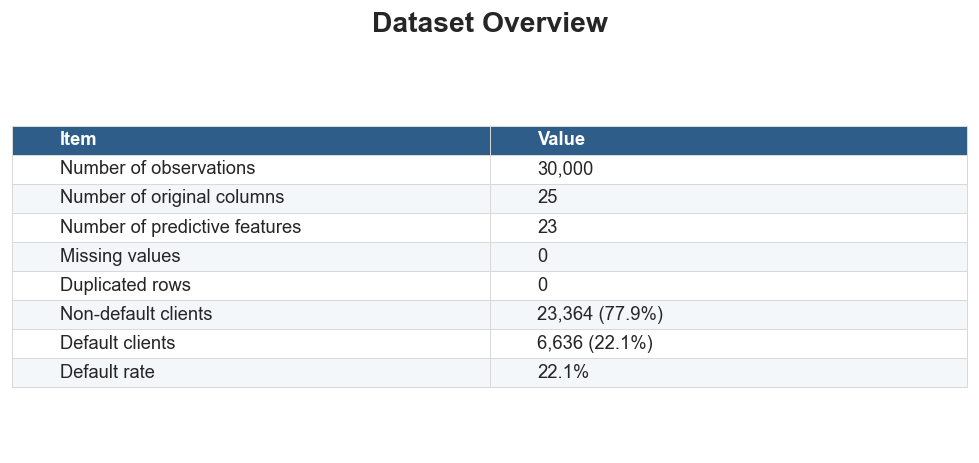

In [25]:
# Cell 5: Publication-style descriptive statistics tables

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================================================
# 1. Dataset overview table
# =========================================================

n_rows = df.shape[0]
n_cols = df.shape[1]
n_missing = int(df.isnull().sum().sum())
n_duplicates = int(df.duplicated().sum())

default_count = int(df_eda[target].sum())
non_default_count = int((df_eda[target] == 0).sum())

default_rate = default_count / n_rows * 100
non_default_rate = non_default_count / n_rows * 100

# ID and target are not predictive features
n_predictive_features = n_cols - 2

overview_table = pd.DataFrame({
    "Item": [
        "Number of observations",
        "Number of original columns",
        "Number of predictive features",
        "Missing values",
        "Duplicated rows",
        "Non-default clients",
        "Default clients",
        "Default rate"
    ],
    "Value": [
        f"{n_rows:,}",
        f"{n_cols}",
        f"{n_predictive_features}",
        f"{n_missing}",
        f"{n_duplicates}",
        f"{non_default_count:,} ({non_default_rate:.1f}%)",
        f"{default_count:,} ({default_rate:.1f}%)",
        f"{default_rate:.1f}%"
    ]
})

display(overview_table)

overview_table.to_csv(OUTPUT_DIR / "dataset_overview_table.csv", index=False)


# =========================================================
# 2. Key descriptive statistics table
# =========================================================

key_features = [
    "LIMIT_BAL",
    "AGE",
    "PAY_0",
    "PAY_2",
    "BILL_AMT1",
    "BILL_AMT2",
    "PAY_AMT1",
    "PAY_AMT2",
    target
]

desc_table = df_eda[key_features].describe().T

desc_table = desc_table[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

# Rename columns for report readability
desc_table = desc_table.rename(columns={
    "count": "Count",
    "mean": "Mean",
    "std": "Std.",
    "min": "Min",
    "25%": "Q1",
    "50%": "Median",
    "75%": "Q3",
    "max": "Max"
})

# More readable formatting
desc_table_formatted = desc_table.copy()

for col in desc_table_formatted.columns:
    if col == "Count":
        desc_table_formatted[col] = desc_table_formatted[col].map(lambda x: f"{x:,.0f}")
    else:
        desc_table_formatted[col] = desc_table_formatted[col].map(lambda x: f"{x:,.2f}")

display(desc_table_formatted)

desc_table_formatted.to_csv(OUTPUT_DIR / "key_descriptive_statistics_table.csv")


# =========================================================
# 3. Save a clean PNG version of the overview table
#    This can be inserted into PPT/report directly.
# =========================================================

def save_table_as_png(table_df, filename, title, figsize=(9, 3.6), font_size=11):
    fig, ax = plt.subplots(figsize=figsize, facecolor="white")
    ax.axis("off")

    ax.set_title(
        title,
        fontsize=17,
        fontweight="bold",
        pad=18
    )

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc="left",
        colLoc="left",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, 1.45)

    # Style cells
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#D9D9D9")
        cell.set_linewidth(0.6)

        if row == 0:
            cell.set_facecolor("#2F5D8A")
            cell.set_text_props(color="white", weight="bold")
        else:
            if row % 2 == 0:
                cell.set_facecolor("#F4F7FA")
            else:
                cell.set_facecolor("white")

    plt.tight_layout()

    path = FIG_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved table figure: {path}")
    plt.show()


save_table_as_png(
    overview_table,
    "02_dataset_overview_table.png",
    "Dataset Overview",
    figsize=(8.5, 4.2),
    font_size=11
)

In [29]:
# Cell 6: Categorical variable distribution check

import pandas as pd
from IPython.display import display

# =========================================================
# Helper function
# =========================================================

def categorical_distribution(data, col, label_col=None):
    """
    Generate count and percentage table for a categorical variable.
    """
    table = data[col].value_counts(dropna=False).sort_index().reset_index()
    table.columns = ["Raw Value", "Count"]
    table["Percentage"] = table["Count"] / len(data) * 100
    table["Percentage"] = table["Percentage"].round(2)
    table.insert(0, "Variable", col)

    if label_col is not None and label_col in data.columns:
        label_map = (
            data[[col, label_col]]
            .drop_duplicates()
            .sort_values(col)
            .set_index(col)[label_col]
            .to_dict()
        )
        table["Label"] = table["Raw Value"].map(label_map)
    else:
        table["Label"] = table["Raw Value"].astype(str)

    return table[["Variable", "Raw Value", "Label", "Count", "Percentage"]]


# =========================================================
# 1. Demographic categorical variables
# =========================================================

sex_dist = categorical_distribution(df_eda, "SEX", "SEX_LABEL")
education_dist = categorical_distribution(df_eda, "EDUCATION", "EDUCATION_LABEL")
marriage_dist = categorical_distribution(df_eda, "MARRIAGE", "MARRIAGE_LABEL")

print("===== SEX distribution =====")
display(sex_dist)

print("===== EDUCATION distribution =====")
display(education_dist)

print("===== MARRIAGE distribution =====")
display(marriage_dist)


# =========================================================
# 2. Repayment status variables
# =========================================================

pay_status_tables = []

for col in pay_status_cols:
    table = categorical_distribution(df_eda, col)
    pay_status_tables.append(table)

    print(f"===== {col} distribution =====")
    display(table)

pay_status_dist = pd.concat(pay_status_tables, ignore_index=True)


# =========================================================
# 3. Encoding issue summary
# =========================================================

education_unknown_count = df_eda["EDUCATION"].isin([0, 5, 6]).sum()
education_unknown_pct = education_unknown_count / len(df_eda) * 100

marriage_unknown_count = (df_eda["MARRIAGE"] == 0).sum()
marriage_unknown_pct = marriage_unknown_count / len(df_eda) * 100

encoding_issue_summary = pd.DataFrame({
    "Issue": [
        "EDUCATION values coded as 0, 5, or 6",
        "MARRIAGE value coded as 0"
    ],
    "Count": [
        education_unknown_count,
        marriage_unknown_count
    ],
    "Percentage": [
        round(education_unknown_pct, 2),
        round(marriage_unknown_pct, 2)
    ],
    "Suggested handling": [
        "Group as Unknown/Others",
        "Group as Unknown/Others"
    ]
})

print("===== Encoding issue summary =====")
display(encoding_issue_summary)


# =========================================================
# 4. Save results
# =========================================================

# Save all categorical variables together
category_dist_all = pd.concat(
    [sex_dist, education_dist, marriage_dist, pay_status_dist],
    ignore_index=True
)

category_dist_all.to_csv(
    OUTPUT_DIR / "categorical_variable_distribution.csv",
    index=False
)

# Save repayment status variables separately
pay_status_dist.to_csv(
    OUTPUT_DIR / "repayment_status_distribution.csv",
    index=False
)

# Save each PAY variable distribution separately
PAY_DIST_DIR = OUTPUT_DIR / "pay_status_distribution"
PAY_DIST_DIR.mkdir(exist_ok=True)

for col in pay_status_cols:
    single_pay_table = categorical_distribution(df_eda, col)
    single_pay_table.to_csv(
        PAY_DIST_DIR / f"{col}_distribution.csv",
        index=False
    )

# Save encoding issue summary
encoding_issue_summary.to_csv(
    OUTPUT_DIR / "encoding_issue_summary.csv",
    index=False
)

print("Saved all categorical distribution to:", OUTPUT_DIR / "categorical_variable_distribution.csv")
print("Saved repayment status distribution to:", OUTPUT_DIR / "repayment_status_distribution.csv")
print("Saved individual PAY distributions to:", PAY_DIST_DIR)
print("Saved encoding issue summary to:", OUTPUT_DIR / "encoding_issue_summary.csv")

===== SEX distribution =====


,Variable,Raw Value,Label,Count,Percentage
0,SEX,1,Male,11888,39.63
1,SEX,2,Female,18112,60.37


===== EDUCATION distribution =====


,Variable,Raw Value,Label,Count,Percentage
0,EDUCATION,0,Unknown/Others,14,0.05
1,EDUCATION,1,Graduate School,10585,35.28
2,EDUCATION,2,University,14030,46.77
3,EDUCATION,3,High School,4917,16.39
4,EDUCATION,4,Others,123,0.41
5,EDUCATION,5,Unknown/Others,280,0.93
6,EDUCATION,6,Unknown/Others,51,0.17


===== MARRIAGE distribution =====


...

===== PAY_6 distribution =====


,Variable,Raw Value,Label,Count,Percentage
0,PAY_6,-2,-2,4895,16.32
1,PAY_6,-1,-1,5740,19.13
2,PAY_6,0,0,16286,54.29
3,PAY_6,2,2,2766,9.22
4,PAY_6,3,3,184,0.61
5,PAY_6,4,4,49,0.16
6,PAY_6,5,5,13,0.04
7,PAY_6,6,6,19,0.06
8,PAY_6,7,7,46,0.15
9,PAY_6,8,8,2,0.01


===== Encoding issue summary =====


,Issue,Count,Percentage,Suggested handling
0,"EDUCATION values coded as 0, 5, or 6",345,1.15,Group as Unknown/Others
1,MARRIAGE value coded as 0,54,0.18,Group as Unknown/Others


Saved all categorical distribution to: outputs\categorical_variable_distribution.csv
Saved repayment status distribution to: outputs\repayment_status_distribution.csv
Saved individual PAY distributions to: outputs\pay_status_distribution
Saved encoding issue summary to: outputs\encoding_issue_summary.csv


,SEX_LABEL,count,Default Rate (%)
1,Male,11888,24.167227
0,Female,18112,20.776281


,EDUCATION_LABEL,count,Default Rate (%)
0,Graduate School,10585,19.234766
3,University,14030,23.734854
1,High School,4917,25.157616
2,Others,123,5.691057
4,Unknown/Others,345,7.536232


,MARRIAGE_LABEL,count,Default Rate (%)
0,Married,13659,23.471704
2,Single,15964,20.928339
1,Others,323,26.006192
3,Unknown/Others,54,9.259259


Saved figure: outputs\eda_figures\03_demographic_default_rate_panels.png


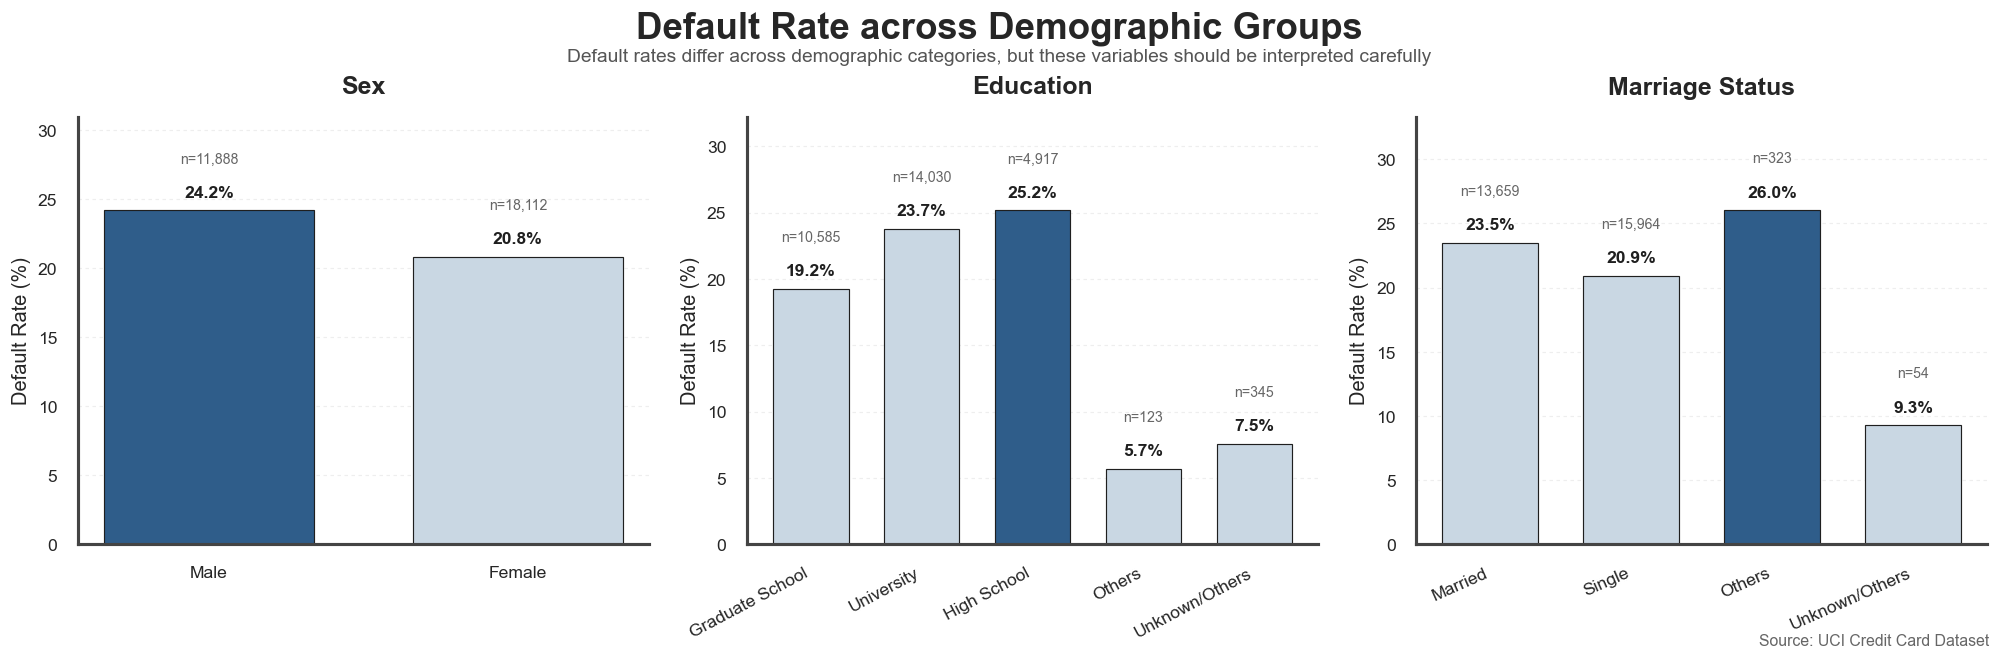

In [31]:
# Cell 7: Demographic variables and default rate
# Publication-style multi-panel plot

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="white", context="talk")

# =========================================================
# 1. Prepare default rate tables
# =========================================================

def get_default_rate_table(data, col, order=None):
    summary = data.groupby(col)[target].agg(["count", "mean"]).reset_index()
    summary["Default Rate (%)"] = summary["mean"] * 100
    summary = summary.drop(columns=["mean"])
    
    if order is not None:
        summary[col] = pd.Categorical(summary[col], categories=order, ordered=True)
        summary = summary.sort_values(col)
    else:
        summary = summary.sort_values("Default Rate (%)", ascending=False)
    
    return summary


sex_order = ["Male", "Female"]
education_order = [
    "Graduate School",
    "University",
    "High School",
    "Others",
    "Unknown/Others"
]
marriage_order = [
    "Married",
    "Single",
    "Others",
    "Unknown/Others"
]

sex_rate = get_default_rate_table(df_eda, "SEX_LABEL", sex_order)
edu_rate = get_default_rate_table(df_eda, "EDUCATION_LABEL", education_order)
marriage_rate = get_default_rate_table(df_eda, "MARRIAGE_LABEL", marriage_order)

display(sex_rate)
display(edu_rate)
display(marriage_rate)

sex_rate.to_csv(OUTPUT_DIR / "default_rate_by_sex.csv", index=False)
edu_rate.to_csv(OUTPUT_DIR / "default_rate_by_education.csv", index=False)
marriage_rate.to_csv(OUTPUT_DIR / "default_rate_by_marriage.csv", index=False)


# =========================================================
# 2. Plot helper
# =========================================================

def plot_rate_panel(ax, data, x_col, title, rotate=0):
    base_color = "#C9D7E3"
    highlight_color = "#2F5D8A"
    
    max_rate = data["Default Rate (%)"].max()
    colors = [
        highlight_color if v == max_rate else base_color
        for v in data["Default Rate (%)"]
    ]
    
    bars = ax.bar(
        data[x_col].astype(str),
        data["Default Rate (%)"],
        color=colors,
        width=0.68,
        edgecolor="#1F1F1F",
        linewidth=0.7
    )
    
    ymax = max(data["Default Rate (%)"].max() * 1.28, 30)
    ax.set_ylim(0, ymax)
    
    # Value labels
    for bar, rate, count in zip(bars, data["Default Rate (%)"], data["count"]):
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        
        ax.text(
            x,
            y + ymax * 0.025,
            f"{rate:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10.5,
            fontweight="bold",
            color="#1F1F1F"
        )
        
        # sample size note under percentage
        ax.text(
            x,
            y + ymax * 0.105,
            f"n={count:,}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            color="#666666"
        )
    
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14)
    ax.set_ylabel("Default Rate (%)", fontsize=12)
    ax.set_xlabel("")
    
    ax.yaxis.grid(True, linestyle=(0, (3, 3)), linewidth=0.7, alpha=0.32)
    ax.xaxis.grid(False)
    
    ax.tick_params(axis="x", labelrotation=rotate, labelsize=10.5)
    ax.tick_params(axis="y", labelsize=10.5)
    
    for label in ax.get_xticklabels():
        label.set_ha("right" if rotate else "center")
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#444444")
    ax.spines["bottom"].set_color("#444444")


# =========================================================
# 3. Multi-panel figure
# =========================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(17, 5.8),
    facecolor="white"
)

fig.suptitle(
    "Default Rate across Demographic Groups",
    fontsize=22,
    fontweight="bold",
    y=0.95
)

fig.text(
    0.5,
    0.885,
    "Default rates differ across demographic categories, but these variables should be interpreted carefully",
    ha="center",
    va="center",
    fontsize=11.5,
    color="#555555"
)

plot_rate_panel(
    axes[0],
    sex_rate,
    "SEX_LABEL",
    "Sex",
    rotate=0
)

plot_rate_panel(
    axes[1],
    edu_rate,
    "EDUCATION_LABEL",
    "Education",
    rotate=28
)

plot_rate_panel(
    axes[2],
    marriage_rate,
    "MARRIAGE_LABEL",
    "Marriage Status",
    rotate=24
)

fig.text(
    0.985,
    0.035,
    "Source: UCI Credit Card Dataset",
    ha="right",
    va="bottom",
    fontsize=9.5,
    color="#666666"
)

plt.subplots_adjust(
    top=0.78,
    bottom=0.22,
    left=0.06,
    right=0.985,
    wspace=0.28
)

save_fig("03_demographic_default_rate_panels.png")
plt.show()

AGE                                     LIMIT_BAL                                                            
                count       mean median       std min max     count           mean    median            std      min        max
Default Status                                                                                                                 
Non-default     23364  35.417266   34.0  9.077355  21  79     23364  178099.726074  150000.0  131628.359660  10000.0  1000000.0
Default          6636  35.725738   34.0  9.693438  21  75      6636  130109.656420   90000.0  115378.540571  10000.0   740000.0

Saved figure: outputs\eda_figures\04_age_credit_limit_by_default_refined.png


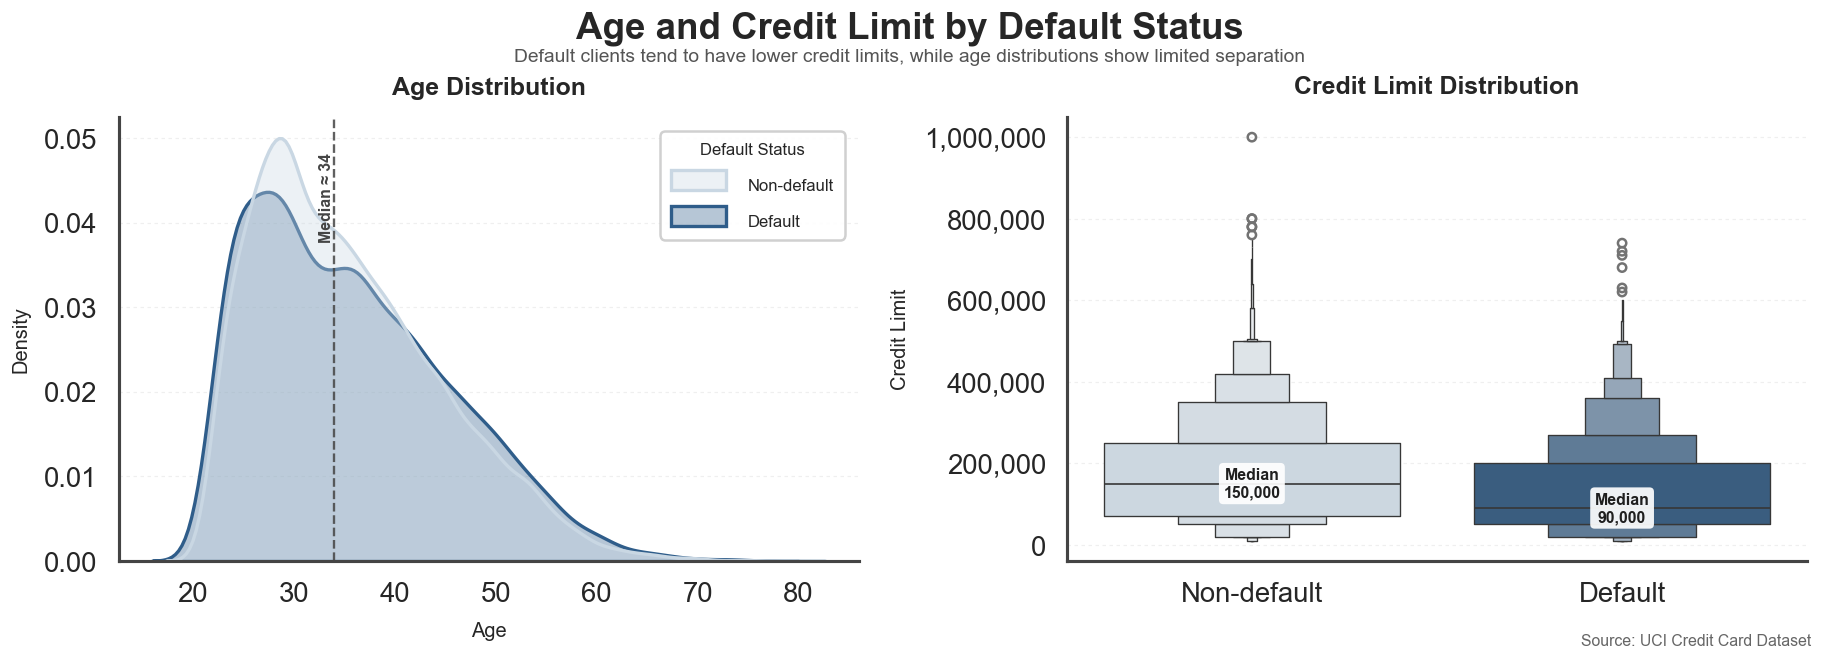

In [35]:
# Cell 8: Age and credit limit distribution by default status
# Refined publication-style two-panel plot

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="white", context="talk")

# =========================================================
# 1. Prepare data
# =========================================================

plot_df = df_eda.copy()
plot_df["Default Status"] = plot_df[target].map({
    0: "Non-default",
    1: "Default"
})

status_order = ["Non-default", "Default"]

palette = {
    "Non-default": "#C9D7E3",
    "Default": "#2F5D8A"
}

age_limit_summary = (
    plot_df
    .groupby("Default Status")[["AGE", "LIMIT_BAL"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .loc[status_order]
)

display(age_limit_summary)

age_limit_summary.to_csv(OUTPUT_DIR / "age_limit_by_default_summary.csv")


# =========================================================
# 2. Create figure
# =========================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(15.5, 5.8),
    facecolor="white"
)

fig.suptitle(
    "Age and Credit Limit by Default Status",
    fontsize=22,
    fontweight="bold",
    y=0.95
)

fig.text(
    0.5,
    0.885,
    "Default clients tend to have lower credit limits, while age distributions show limited separation",
    ha="center",
    va="center",
    fontsize=11.5,
    color="#555555"
)


# =========================================================
# 3. Panel A: Age distribution
# =========================================================

ax = axes[0]

sns.kdeplot(
    data=plot_df,
    x="AGE",
    hue="Default Status",
    hue_order=status_order,
    fill=True,
    common_norm=False,
    alpha=0.35,
    linewidth=2.0,
    palette=palette,
    ax=ax
)

# Median age: if medians are identical or very close, use one concise note
median_age_table = plot_df.groupby("Default Status")["AGE"].median().loc[status_order]
median_non_default = median_age_table["Non-default"]
median_default = median_age_table["Default"]

if abs(median_non_default - median_default) <= 1:
    median_age = np.mean([median_non_default, median_default])
    ax.axvline(
        median_age,
        color="#444444",
        linestyle="--",
        linewidth=1.4,
        alpha=0.85
    )
    ax.text(
        median_age,
        ax.get_ylim()[1] * 0.92,
        f"Median ≈ {median_age:.0f}",
        rotation=90,
        va="top",
        ha="right",
        fontsize=9.5,
        color="#444444",
        fontweight="bold"
    )
else:
    for status in status_order:
        color = palette[status]
        median_age = median_age_table[status]
        ax.axvline(
            median_age,
            color=color,
            linestyle="--",
            linewidth=1.4,
            alpha=0.85
        )
        ax.text(
            median_age,
            ax.get_ylim()[1] * 0.92,
            f"{status}\nMedian: {median_age:.0f}",
            rotation=90,
            va="top",
            ha="right",
            fontsize=8.8,
            color=color,
            fontweight="bold"
        )

ax.set_title("Age Distribution", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Age", fontsize=12, labelpad=8)
ax.set_ylabel("Density", fontsize=12, labelpad=8)

ax.yaxis.grid(True, linestyle=(0, (3, 3)), linewidth=0.7, alpha=0.30)
ax.xaxis.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")

# Make legend smaller and less intrusive
legend = ax.get_legend()
if legend is not None:
    legend.set_title("Default Status")
    legend.get_title().set_fontsize(10)
    for text in legend.get_texts():
        text.set_fontsize(10)
    legend.get_frame().set_alpha(0.92)


# =========================================================
# 4. Panel B: Credit limit distribution
# =========================================================

ax = axes[1]

sns.boxenplot(
    data=plot_df,
    x="Default Status",
    y="LIMIT_BAL",
    order=status_order,
    palette=palette,
    linewidth=0.8,
    ax=ax
)

# Correct median labels using the same x-axis order
medians = plot_df.groupby("Default Status")["LIMIT_BAL"].median().loc[status_order]

for i, status in enumerate(status_order):
    median_val = medians[status]
    ax.text(
        i,
        median_val,
        f"Median\n{median_val:,.0f}",
        ha="center",
        va="center",
        fontsize=9.5,
        fontweight="bold",
        color="#1F1F1F",
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor="white",
            edgecolor="none",
            alpha=0.92
        )
    )

ax.set_title("Credit Limit Distribution", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("")
ax.set_ylabel("Credit Limit", fontsize=12, labelpad=8)

ax.yaxis.grid(True, linestyle=(0, (3, 3)), linewidth=0.7, alpha=0.30)
ax.xaxis.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")

ax.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"{int(x):,}")
)


# =========================================================
# 5. Source note and save
# =========================================================

fig.text(
    0.985,
    0.035,
    "Source: UCI Credit Card Dataset",
    ha="right",
    va="bottom",
    fontsize=9.5,
    color="#666666"
)

plt.subplots_adjust(
    top=0.78,
    bottom=0.16,
    left=0.07,
    right=0.985,
    wspace=0.24
)

save_fig("04_age_credit_limit_by_default_refined.png")
plt.show()

,Repayment Status,count,Default Rate (%),Feature
0,-2,2759,13.229431,PAY_0
1,-1,5686,16.778051,PAY_0
2,0,14737,12.811291,PAY_0
3,1,3688,33.947939,PAY_0
4,2,2667,69.141357,PAY_0
...,...,...,...,...
59,4,49,63.265306,PAY_6
60,5,13,53.846154,PAY_6
61,6,19,73.684211,PAY_6
62,7,46,82.608696,PAY_6


,Repayment Status,count,Default Rate (%),Feature
0,-2,2759,13.229431,PAY_0
1,-1,5686,16.778051,PAY_0
2,0,14737,12.811291,PAY_0
3,1,3688,33.947939,PAY_0
4,2,2667,69.141357,PAY_0
5,3,322,75.776398,PAY_0
6,4,76,68.421053,PAY_0
7,5,26,50.000000,PAY_0
8,6,11,54.545455,PAY_0
9,7,9,77.777778,PAY_0


,PAY_0_GROUP,count,Default Rate (%)
0,≤0,23182,13.834009
1,1,3688,33.947939
2,2,2667,69.141357
3,3,322,75.776398
4,4+,141,63.120567


Saved figure: outputs\eda_figures\05_default_rate_by_PAY_0_grouped_final.png


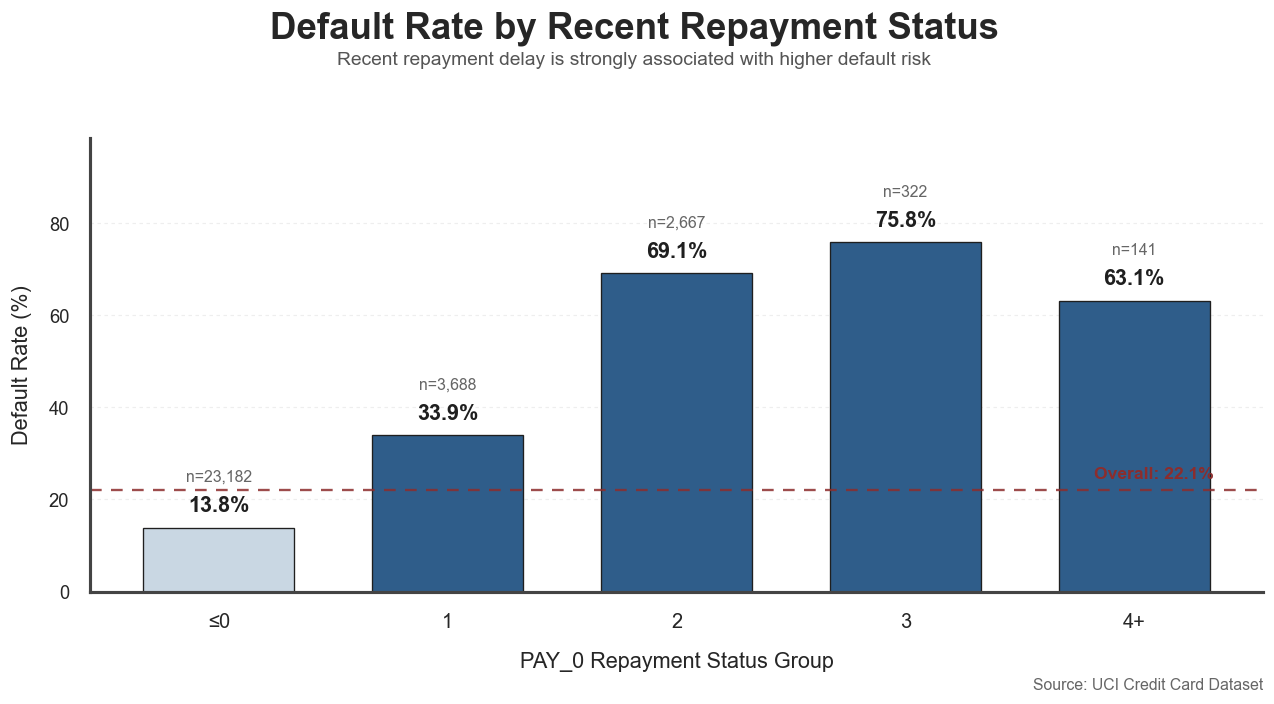

Feature,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
Status Group,,,,,,
≤0,13.83,16.27,17.19,17.96,18.45,18.67
1,33.95,17.86,25.00,50.00,NaN,NaN
2,69.14,55.61,51.56,52.33,54.19,50.65
3,75.78,61.66,57.50,61.11,63.48,64.13
4+,63.12,54.78,62.67,68.05,68.90,71.32


Feature,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
Status Group,,,,,,
≤0,23182,25562,25787,26490,27032,26921
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4+,141,157,150,169,164,129


Saved figure: outputs\eda_figures\06_grouped_repayment_status_default_rate_heatmap_final.png


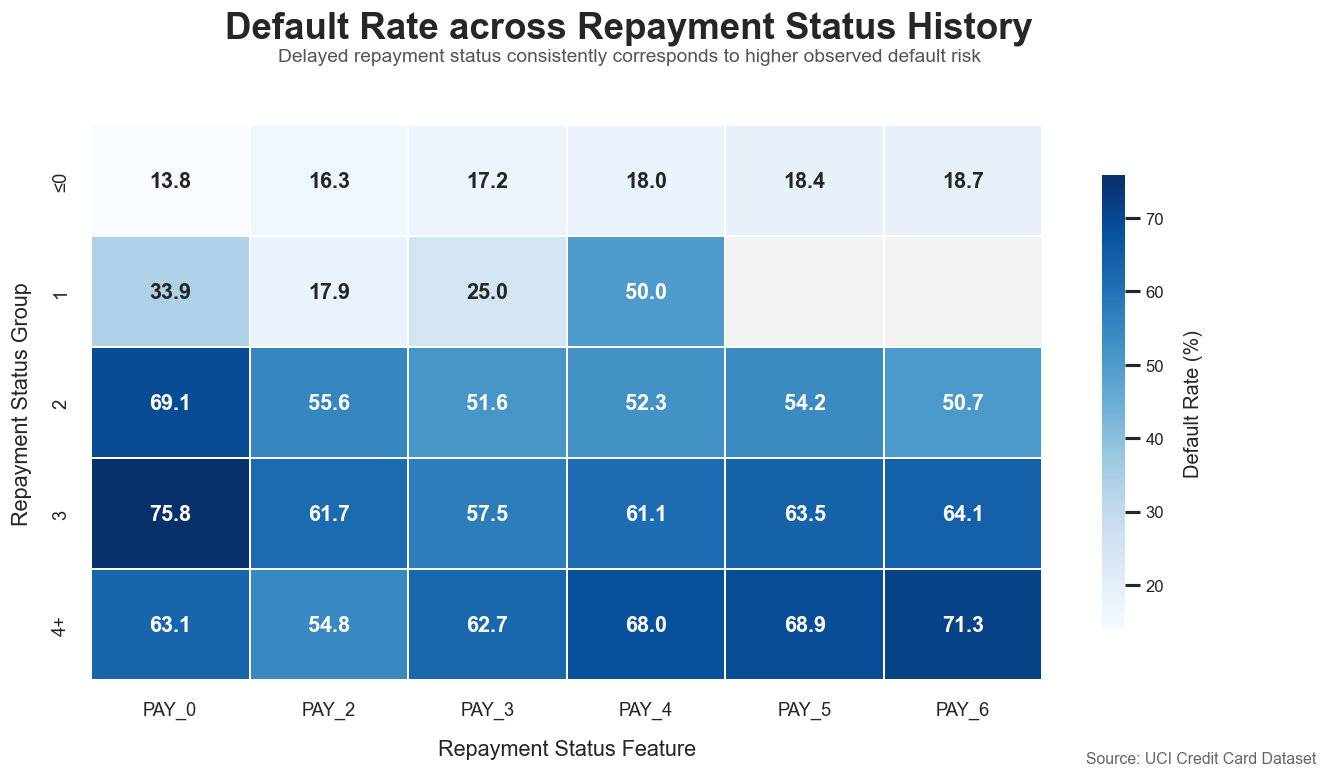

In [55]:
# Cell 9: Repayment status and default risk
# Publication-style PAY_0 bar chart + repayment status heatmap

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="white", context="talk")

# =========================================================
# 1. Prepare repayment status default-rate tables
# =========================================================

pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

all_pay_rate_tables = []

for col in pay_status_cols:
    summary = (
        df_eda
        .groupby(col)[target]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={col: "Repayment Status"})
    )
    
    summary["Default Rate (%)"] = summary["mean"] * 100
    summary["Feature"] = col
    summary = summary.drop(columns=["mean"])
    
    all_pay_rate_tables.append(summary)

pay_rate_all = pd.concat(all_pay_rate_tables, ignore_index=True)

display(pay_rate_all)

pay_rate_all.to_csv(
    OUTPUT_DIR / "repayment_status_default_rate_all.csv",
    index=False
)

# PAY_0 table for detailed display
pay0_rate = pay_rate_all[pay_rate_all["Feature"] == "PAY_0"].copy()
pay0_rate = pay0_rate.sort_values("Repayment Status")

display(pay0_rate)

pay0_rate.to_csv(
    OUTPUT_DIR / "default_rate_by_PAY_0.csv",
    index=False
)


# =========================================================
# 2. Figure A: Grouped PAY_0 default rate bar chart
#    More stable and presentation-friendly
# =========================================================

pay0_grouped = df_eda.copy()

def group_pay0_status(x):
    if x <= 0:
        return "≤0"
    elif x in [1, 2, 3]:
        return str(int(x))
    else:
        return "4+"

pay0_grouped["PAY_0_GROUP"] = pay0_grouped["PAY_0"].apply(group_pay0_status)

pay0_group_order = ["≤0", "1", "2", "3", "4+"]

pay0_group_rate = (
    pay0_grouped
    .groupby("PAY_0_GROUP")[target]
    .agg(["count", "mean"])
    .reindex(pay0_group_order)
    .reset_index()
)

pay0_group_rate["Default Rate (%)"] = pay0_group_rate["mean"] * 100
pay0_group_rate = pay0_group_rate.drop(columns=["mean"])

display(pay0_group_rate)

pay0_group_rate.to_csv(
    OUTPUT_DIR / "default_rate_by_PAY_0_grouped.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(10.8, 6.2), facecolor="white")

colors = [
    "#C9D7E3" if status == "≤0" else "#2F5D8A"
    for status in pay0_group_rate["PAY_0_GROUP"]
]

bars = ax.bar(
    pay0_group_rate["PAY_0_GROUP"],
    pay0_group_rate["Default Rate (%)"],
    color=colors,
    width=0.66,
    edgecolor="#1F1F1F",
    linewidth=0.8
)

ymax = pay0_group_rate["Default Rate (%)"].max()
ax.set_ylim(0, ymax * 1.30)

# Value labels and sample sizes
for bar, rate, count in zip(
    bars,
    pay0_group_rate["Default Rate (%)"],
    pay0_group_rate["count"]
):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()

    ax.text(
        x,
        y + ymax * 0.035,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color="#1F1F1F"
    )

    ax.text(
        x,
        y + ymax * 0.125,
        f"n={count:,}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        color="#666666"
    )

# Overall default rate reference line
overall_default_rate = df_eda[target].mean() * 100

ax.axhline(
    overall_default_rate,
    color="#8C2D2D",
    linestyle=(0, (5, 4)),
    linewidth=1.4,
    alpha=0.85
)

ax.text(
    4.35,
    overall_default_rate + ymax * 0.025,
    f"Overall: {overall_default_rate:.1f}%",
    ha="right",
    va="bottom",
    fontsize=10.5,
    color="#8C2D2D",
    fontweight="bold"
)

# Titles
fig.suptitle(
    "Default Rate by Recent Repayment Status",
    fontsize=22,
    fontweight="bold",
    y=0.95
)

fig.text(
    0.5,
    0.885,
    "Recent repayment delay is strongly associated with higher default risk",
    ha="center",
    va="center",
    fontsize=11.5,
    color="#555555"
)

# Axis labels
ax.set_xlabel("PAY_0 Repayment Status Group", fontsize=13, labelpad=12)
ax.set_ylabel("Default Rate (%)", fontsize=13, labelpad=10)

ax.yaxis.grid(True, linestyle=(0, (3, 3)), linewidth=0.7, alpha=0.32)
ax.xaxis.grid(False)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")

# Source note only, no long bottom note
fig.text(
    0.985,
    0.035,
    "Source: UCI Credit Card Dataset",
    ha="right",
    va="bottom",
    fontsize=9.5,
    color="#666666"
)

plt.subplots_adjust(
    top=0.78,
    bottom=0.17,
    left=0.08,
    right=0.985
)

# IMPORTANT:
# Do not use save_fig() here, because save_fig may call tight_layout()
# and destroy the manual spacing.
path = FIG_DIR / "05_default_rate_by_PAY_0_grouped_final.png"
fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved figure: {path}")

plt.show()

# =========================================================
# 3. Figure B: Grouped repayment status heatmap across six months
#    Robust version: handles missing groups safely
# =========================================================

def group_pay_status(x):
    if x <= 0:
        return "≤0"
    elif x in [1, 2, 3]:
        return str(int(x))
    else:
        return "4+"

status_group_order = ["≤0", "1", "2", "3", "4+"]

grouped_heatmap_tables = []
grouped_count_tables = []

for col in pay_status_cols:
    temp = df_eda[[col, target]].copy()
    temp["Status Group"] = temp[col].apply(group_pay_status)
    
    summary = (
        temp
        .groupby("Status Group")[target]
        .agg(["count", "mean"])
        .reindex(status_group_order)
        .reset_index()
    )
    
    summary["Feature"] = col
    summary["Default Rate (%)"] = summary["mean"] * 100
    
    grouped_heatmap_tables.append(
        summary[["Status Group", "Feature", "Default Rate (%)"]]
    )
    
    grouped_count_tables.append(
        summary[["Status Group", "Feature", "count"]]
    )

grouped_heatmap_all = pd.concat(grouped_heatmap_tables, ignore_index=True)
grouped_count_all = pd.concat(grouped_count_tables, ignore_index=True)

heatmap_grouped_df = grouped_heatmap_all.pivot(
    index="Status Group",
    columns="Feature",
    values="Default Rate (%)"
).reindex(index=status_group_order, columns=pay_status_cols)

count_grouped_df = grouped_count_all.pivot(
    index="Status Group",
    columns="Feature",
    values="count"
).reindex(index=status_group_order, columns=pay_status_cols)

# Count table: missing groups mean zero samples
count_grouped_df_filled = count_grouped_df.fillna(0).astype(int)

display(heatmap_grouped_df.round(2))
display(count_grouped_df_filled)

heatmap_grouped_df.to_csv(OUTPUT_DIR / "grouped_repayment_status_default_rate_heatmap.csv")
count_grouped_df_filled.to_csv(OUTPUT_DIR / "grouped_repayment_status_count_heatmap.csv")


# =========================================================
# Plot grouped heatmap
# =========================================================

fig, ax = plt.subplots(figsize=(11.8, 6.8), facecolor="white")

# Missing cells are groups with no samples
mask = heatmap_grouped_df.isna()

cmap = plt.cm.Blues.copy()
cmap.set_bad(color="#F2F2F2")

sns.heatmap(
    heatmap_grouped_df,
    cmap=cmap,
    annot=True,
    fmt=".1f",
    mask=mask,
    linewidths=1.0,
    linecolor="white",
    cbar_kws={
        "label": "Default Rate (%)",
        "shrink": 0.82
    },
    annot_kws={
        "fontsize": 13,
        "fontweight": "bold"
    },
    ax=ax
)

fig.suptitle(
    "Default Rate across Repayment Status History",
    fontsize=22,
    fontweight="bold",
    y=0.96
)

fig.text(
    0.5,
    0.905,
    "Delayed repayment status consistently corresponds to higher observed default risk",
    ha="center",
    va="center",
    fontsize=11.5,
    color="#555555"
)

ax.set_xlabel("Repayment Status Feature", fontsize=13, labelpad=12)
ax.set_ylabel("Repayment Status Group", fontsize=13, labelpad=12)

ax.tick_params(axis="x", labelrotation=0, labelsize=11)
ax.tick_params(axis="y", labelsize=11)

# Colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Default Rate (%)", fontsize=12, labelpad=12)

fig.text(
    0.985,
    0.035,
    "Source: UCI Credit Card Dataset",
    ha="right",
    va="bottom",
    fontsize=9.5,
    color="#666666"
)

plt.subplots_adjust(
    top=0.82,
    bottom=0.14,
    left=0.12,
    right=0.96
)

path = FIG_DIR / "06_grouped_repayment_status_default_rate_heatmap_final.png"
fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved figure: {path}")

plt.show()

,Period,Feature,Default Status,Median,Mean,Q1,Q3,Value Type
0,1,BILL_AMT1,Non-default,23119.5,51994.227273,3677.25,69027.00,Bill Amount
1,1,BILL_AMT1,Default,20185.0,48509.162297,2987.75,59626.50,Bill Amount
2,2,BILL_AMT2,Non-default,21660.5,49717.435670,3055.00,65686.00,Bill Amount
3,2,BILL_AMT2,Default,20300.5,47283.617842,2694.00,57919.75,Bill Amount
4,3,BILL_AMT3,Non-default,20202.5,47533.365605,2769.75,61894.00,Bill Amount
5,3,BILL_AMT3,Default,19834.5,45181.598855,2500.00,54733.75,Bill Amount
6,4,BILL_AMT4,Non-default,19000.0,43611.165254,2360.00,55988.00,Bill Amount
7,4,BILL_AMT4,Default,19119.5,42036.950573,2141.50,50175.75,Bill Amount
8,5,BILL_AMT5,Non-default,17998.0,40530.445343,1823.00,51135.25,Bill Amount
9,5,BILL_AMT5,Default,18478.5,39540.190476,1502.75,47853.00,Bill Amount


,Period,Feature,Default Status,Median,Mean,Q1,Q3,Value Type
0,1,PAY_AMT1,Non-default,2459.5,6307.337357,1163.75,5606.25,Payment Amount
1,1,PAY_AMT1,Default,1636.0,3397.044153,0.00,3478.25,Payment Amount
2,2,PAY_AMT2,Non-default,2247.5,6640.465074,1005.00,5311.25,Payment Amount
3,2,PAY_AMT2,Default,1533.5,3388.649638,0.00,3309.75,Payment Amount
4,3,PAY_AMT3,Non-default,2000.0,5753.496833,600.00,5000.00,Payment Amount
5,3,PAY_AMT3,Default,1222.0,3367.351567,0.00,3000.00,Payment Amount
6,4,PAY_AMT4,Non-default,1734.0,5300.529319,390.00,4602.00,Payment Amount
7,4,PAY_AMT4,Default,1000.0,3155.626733,0.00,2939.25,Payment Amount
8,5,PAY_AMT5,Non-default,1765.0,5248.220296,369.00,4600.00,Payment Amount
9,5,PAY_AMT5,Default,1000.0,3219.139542,0.00,3000.00,Payment Amount


Saved figure: outputs\eda_figures\07_billing_payment_patterns_by_default_refined.png


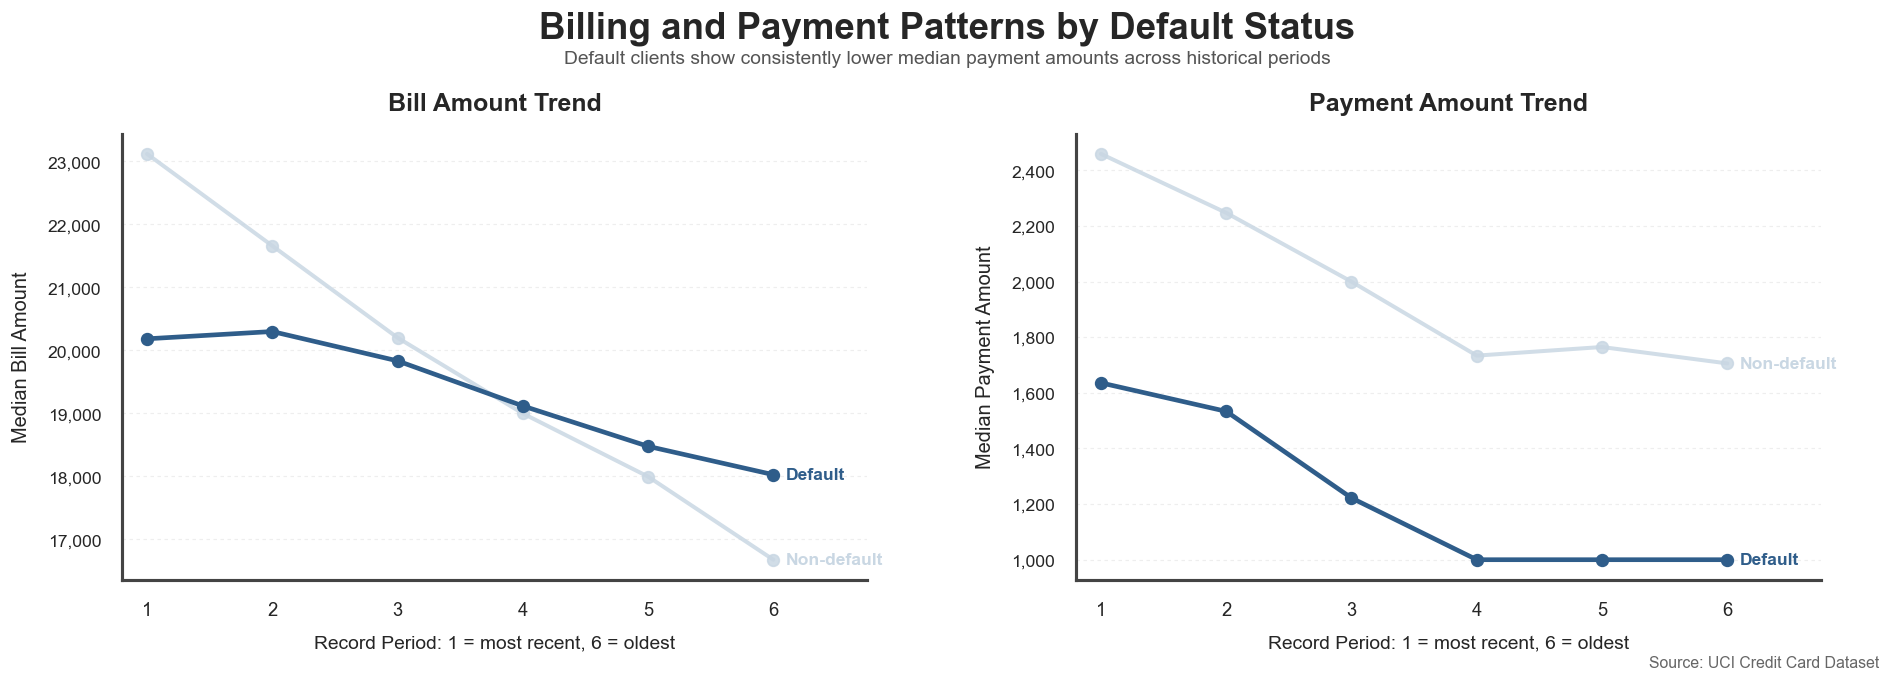

In [59]:
# Cell 10 refined: Monetary variable trends by default status
# Cleaner median-trend version with direct labels

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="white", context="talk")

# =========================================================
# 1. Prepare data
# =========================================================

plot_df = df_eda.copy()
plot_df["Default Status"] = plot_df[target].map({
    0: "Non-default",
    1: "Default"
})

status_order = ["Non-default", "Default"]

palette = {
    "Non-default": "#C9D7E3",
    "Default": "#2F5D8A"
}

bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

period_labels = ["1", "2", "3", "4", "5", "6"]


def make_monetary_summary(data, cols, value_name):
    records = []
    
    for i, col in enumerate(cols, start=1):
        for status in status_order:
            values = data.loc[data["Default Status"] == status, col]
            
            records.append({
                "Period": i,
                "Feature": col,
                "Default Status": status,
                "Median": values.median(),
                "Mean": values.mean(),
                "Q1": values.quantile(0.25),
                "Q3": values.quantile(0.75),
                "Value Type": value_name
            })
    
    return pd.DataFrame(records)


bill_summary = make_monetary_summary(plot_df, bill_cols, "Bill Amount")
pay_summary = make_monetary_summary(plot_df, pay_amt_cols, "Payment Amount")

display(bill_summary)
display(pay_summary)

bill_summary.to_csv(OUTPUT_DIR / "bill_amount_trend_by_default.csv", index=False)
pay_summary.to_csv(OUTPUT_DIR / "payment_amount_trend_by_default.csv", index=False)


# =========================================================
# 2. Plot helper
# =========================================================

def plot_clean_trend_panel(ax, summary_df, title, y_label):
    for status in status_order:
        temp = summary_df[summary_df["Default Status"] == status].sort_values("Period")
        color = palette[status]
        line_width = 2.8 if status == "Default" else 2.4
        alpha = 1.0 if status == "Default" else 0.85
        
        ax.plot(
            temp["Period"],
            temp["Median"],
            marker="o",
            markersize=7,
            linewidth=line_width,
            color=color,
            alpha=alpha
        )
        
        # Endpoint direct label
        last_x = temp["Period"].iloc[-1]
        last_y = temp["Median"].iloc[-1]
        
        ax.text(
            last_x + 0.10,
            last_y,
            status,
            ha="left",
            va="center",
            fontsize=10.5,
            fontweight="bold",
            color=color
        )
    
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14)
    ax.set_xlabel("Record Period: 1 = most recent, 6 = oldest", fontsize=11.5, labelpad=10)
    ax.set_ylabel(y_label, fontsize=12, labelpad=10)
    
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.set_xticklabels(period_labels)
    ax.set_xlim(0.8, 6.75)
    
    ax.yaxis.grid(True, linestyle=(0, (3, 3)), linewidth=0.7, alpha=0.32)
    ax.xaxis.grid(False)
    
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=10.5)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#444444")
    ax.spines["bottom"].set_color("#444444")
    
    ax.get_yaxis().set_major_formatter(
        plt.FuncFormatter(lambda x, p: f"{int(x):,}")
    )


# =========================================================
# 3. Create refined figure
# =========================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    facecolor="white"
)

fig.suptitle(
    "Billing and Payment Patterns by Default Status",
    fontsize=22,
    fontweight="bold",
    y=0.95
)

fig.text(
    0.5,
    0.885,
    "Default clients show consistently lower median payment amounts across historical periods",
    ha="center",
    va="center",
    fontsize=11.5,
    color="#555555"
)

plot_clean_trend_panel(
    axes[0],
    bill_summary,
    "Bill Amount Trend",
    "Median Bill Amount"
)

plot_clean_trend_panel(
    axes[1],
    pay_summary,
    "Payment Amount Trend",
    "Median Payment Amount"
)

fig.text(
    0.985,
    0.035,
    "Source: UCI Credit Card Dataset",
    ha="right",
    va="bottom",
    fontsize=9.5,
    color="#666666"
)

plt.subplots_adjust(
    top=0.78,
    bottom=0.16,
    left=0.07,
    right=0.955,
    wspace=0.28
)

path = FIG_DIR / "07_billing_payment_patterns_by_default_refined.png"
fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved figure: {path}")

plt.show()

,Correlation with Default
PAY_0,0.324794
PAY_2,0.263551
PAY_3,0.235253
PAY_4,0.216614
PAY_5,0.204149
PAY_6,0.186866
LIMIT_BAL,-0.153520
PAY_AMT1,-0.072929
PAY_AMT2,-0.058579
PAY_AMT4,-0.056827


Saved figure: outputs\eda_figures\08_top_correlations_with_default_refined.png


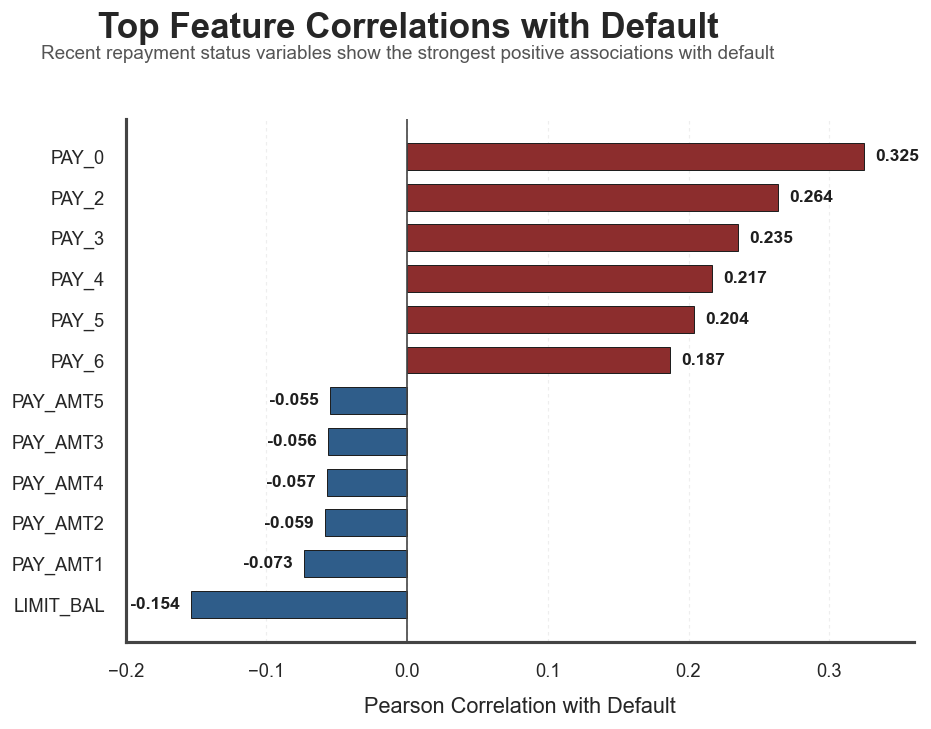

Saved figure: outputs\eda_figures\09_feature_correlation_heatmap.png


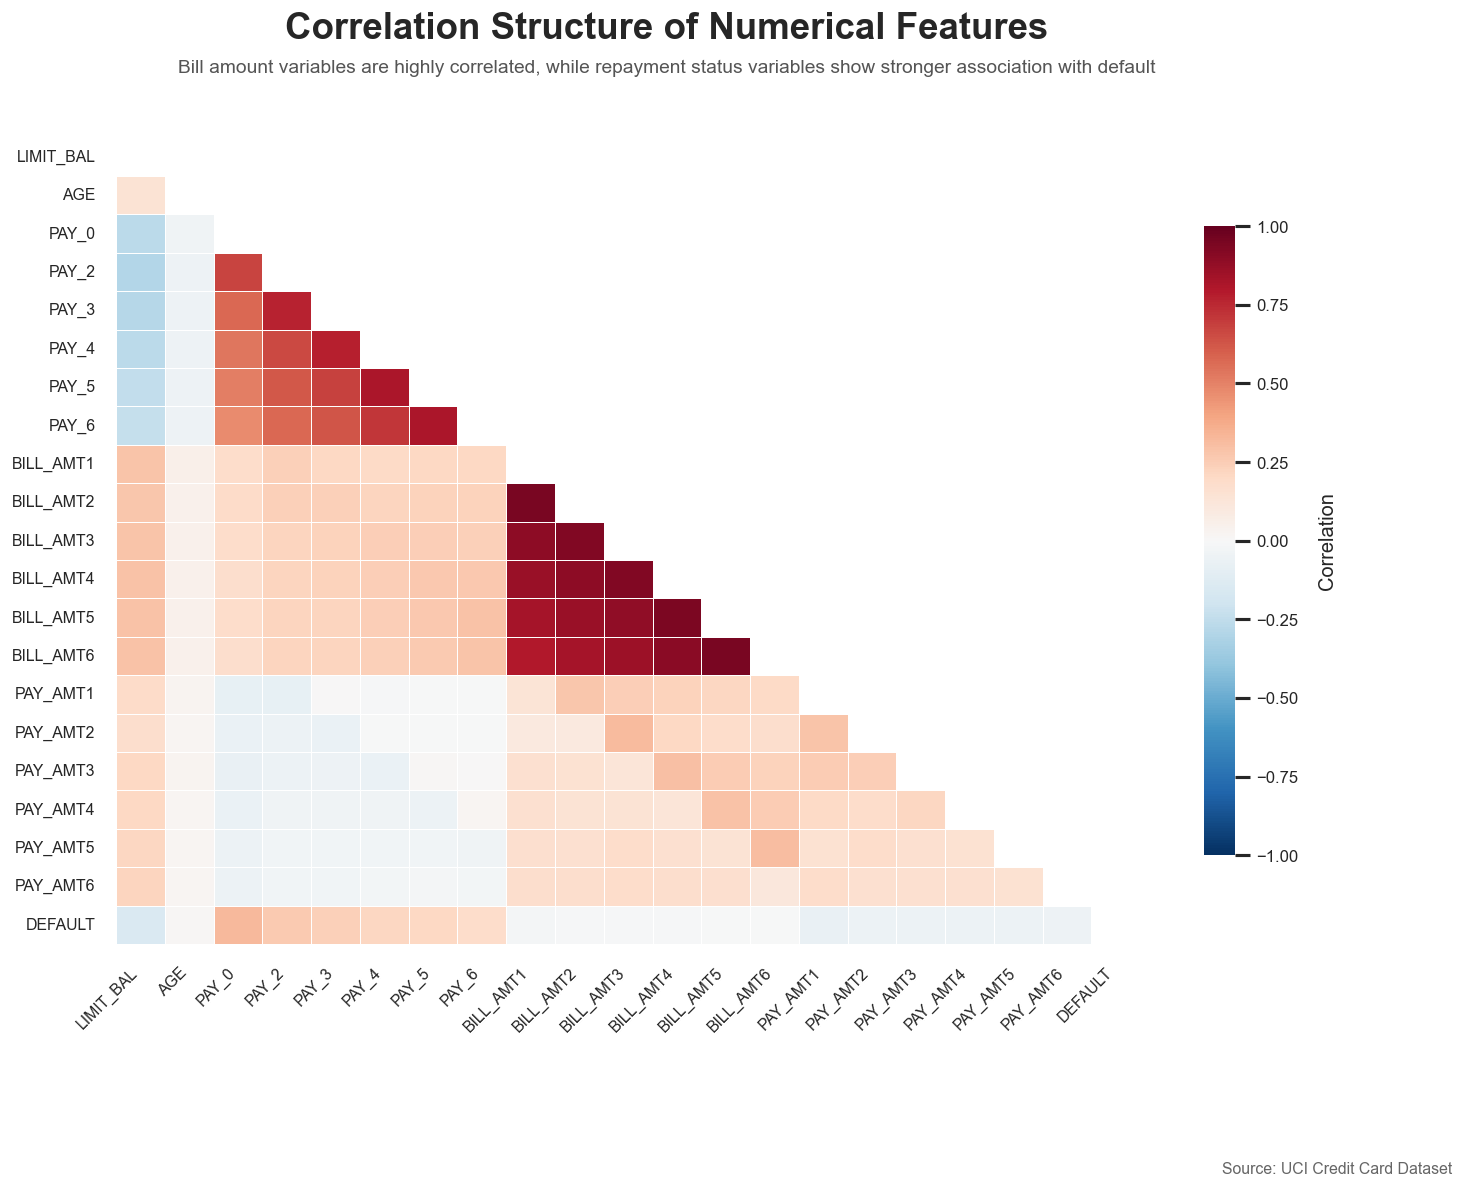

In [63]:
# Cell 11: Correlation analysis
# Publication-style target correlation ranking + feature correlation heatmap

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="white", context="talk")

# =========================================================
# 1. Prepare correlation data
# =========================================================

corr_cols = (
    ["LIMIT_BAL", "AGE"]
    + pay_status_cols
    + bill_cols
    + pay_amt_cols
    + [target]
)

corr_df = df_eda[corr_cols].corr()

# Correlation with target
target_corr = (
    corr_df[target]
    .drop(target)
    .sort_values(key=lambda x: abs(x), ascending=False)
)

target_corr_df = target_corr.to_frame("Correlation with Default")
display(target_corr_df)

target_corr_df.to_csv(OUTPUT_DIR / "target_correlation_ranking.csv")


# =========================================================
# 2. Figure A: Top correlations with default
#    Refined version
# =========================================================

top_n = 12
top_corr = target_corr.head(top_n).sort_values()

fig, ax = plt.subplots(figsize=(9.8, 6.4), facecolor="white")

colors = [
    "#8C2D2D" if value > 0 else "#2F5D8A"
    for value in top_corr.values
]

bars = ax.barh(
    top_corr.index,
    top_corr.values,
    color=colors,
    edgecolor="#1F1F1F",
    linewidth=0.6,
    height=0.66
)

# Better x-limits to avoid label overlap
ax.set_xlim(-0.20, 0.36)

# Reference line at zero
ax.axvline(
    0,
    color="#444444",
    linewidth=1.0
)

# Value labels
for bar, value in zip(bars, top_corr.values):
    y = bar.get_y() + bar.get_height() / 2
    
    if value >= 0:
        label_x = value + 0.008
        ha = "left"
    else:
        label_x = value - 0.008
        ha = "right"
    
    ax.text(
        label_x,
        y,
        f"{value:.3f}",
        va="center",
        ha=ha,
        fontsize=10.5,
        fontweight="bold",
        color="#1F1F1F"
    )

fig.suptitle(
    "Top Feature Correlations with Default",
    fontsize=21,
    fontweight="bold",
    y=0.96
)

fig.text(
    0.5,
    0.905,
    "Recent repayment status variables show the strongest positive associations with default",
    ha="center",
    va="center",
    fontsize=11.3,
    color="#555555"
)

ax.set_xlabel("Pearson Correlation with Default", fontsize=13, labelpad=10)
ax.set_ylabel("")

ax.xaxis.grid(True, linestyle=(0, (3, 3)), linewidth=0.7, alpha=0.32)
ax.yaxis.grid(False)

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")

plt.subplots_adjust(
    top=0.82,
    bottom=0.14,
    left=0.26,
    right=0.93
)

path = FIG_DIR / "08_top_correlations_with_default_refined.png"
fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved figure: {path}")

plt.show()

# =========================================================
# 3. Figure B: Full feature correlation heatmap
# =========================================================

fig, ax = plt.subplots(figsize=(13.5, 10.5), facecolor="white")

# Mask upper triangle for a cleaner academic heatmap
mask = np.triu(np.ones_like(corr_df, dtype=bool))

sns.heatmap(
    corr_df,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.35,
    linecolor="white",
    cbar_kws={
        "label": "Correlation",
        "shrink": 0.78
    },
    ax=ax
)

fig.suptitle(
    "Correlation Structure of Numerical Features",
    fontsize=22,
    fontweight="bold",
    y=0.96
)

fig.text(
    0.5,
    0.915,
    "Bill amount variables are highly correlated, while repayment status variables show stronger association with default",
    ha="center",
    va="center",
    fontsize=11.5,
    color="#555555"
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(axis="x", labelrotation=45, labelsize=9.5)
ax.tick_params(axis="y", labelrotation=0, labelsize=9.5)

# Align x labels
for label in ax.get_xticklabels():
    label.set_ha("right")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Correlation", fontsize=12, labelpad=12)

fig.text(
    0.985,
    0.035,
    "Source: UCI Credit Card Dataset",
    ha="right",
    va="bottom",
    fontsize=9.5,
    color="#666666"
)

plt.subplots_adjust(
    top=0.86,
    bottom=0.22,
    left=0.16,
    right=0.95
)

path = FIG_DIR / "09_feature_correlation_heatmap.png"
fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved figure: {path}")

plt.show()

Number of behavior features created: 17
Behavior features:
['delay_count', 'severe_delay_count', 'max_delay', 'avg_delay', 'recent_delay', 'recent_delay_flag', 'avg_bill_amt', 'max_bill_amt', 'recent_bill_amt', 'bill_trend', 'credit_utilization', 'avg_pay_amt', 'max_pay_amt', 'recent_pay_amt', 'pay_trend', 'recent_pay_bill_ratio', 'total_pay_bill_ratio']


,count,mean,std,min,25%,50%,75%,max
delay_count,30000.0,0.834200,1.554303,0.000000,0.000000,0.000000,1.000000,6.000000e+00
severe_delay_count,30000.0,0.710133,1.464712,0.000000,0.000000,0.000000,1.000000,6.000000e+00
max_delay,30000.0,0.438733,1.345154,-2.000000,0.000000,0.000000,2.000000,8.000000e+00
avg_delay,30000.0,-0.182439,0.982176,-2.000000,-0.833333,0.000000,0.000000,6.000000e+00
recent_delay,30000.0,-0.016700,1.123802,-2.000000,-1.000000,0.000000,0.000000,8.000000e+00
recent_delay_flag,30000.0,0.227267,0.419073,0.000000,0.000000,0.000000,0.000000,1.000000e+00
avg_bill_amt,30000.0,44976.945200,63260.721860,-56043.166667,4781.333333,21051.833333,57104.416667,8.773138e+05
max_bill_amt,30000.0,60572.436867,78404.814025,-6029.000000,10060.000000,31208.500000,79599.000000,1.664089e+06
recent_bill_amt,30000.0,51223.330900,73635.860576,-165580.000000,3558.750000,22381.500000,67091.000000,9.645110e+05
bill_trend,30000.0,12351.570500,43922.421534,-428791.000000,-2963.000000,923.000000,19793.750000,7.083230e+05


delay_count        severe_delay_count        max_delay        avg_delay           recent_delay        recent_delay_flag         avg_bill_amt                max_bill_amt           \
               mean median               mean median      mean median      mean    median         mean median              mean median          mean        median          mean   median   
DEFAULT                                                                                                                                                                                     
0          0.504194    0.0           0.398776    0.0  0.201421    0.0 -0.330023  0.000000    -0.211222    0.0          0.145052    0.0  45404.817975  21443.416667  62281.977016  33780.0   
1          1.996082    1.0           1.806359    1.0  1.274262    2.0  0.337176  0.333333     0.668174    1.0          0.516727    1.0  43470.492591  19781.333333  54553.495329  27685.0   

        recent_bill_amt             bill_trend         credit_utilization            avg_pay_amt                max_pay_amt         recent_pay_amt           pay_trend        recent_pay_bill_ratio  \
                   mean   median          mean  median               mean    median         mean       median          mean  median           mean  median        mean median                  mean   
DEFAULT                                                                                                                                                                                               
0          51994.227273  23119.5  12951.958569  1593.0           0.404876  0.267498  5828.236775  2754.000000  17502.722393  5300.0    6307.337357  2459.5  587.965588  600.0              6.469961   
1          48509.162297  20185.0  10237.726793     0.0           0.490297  0.492875  3328.215617  1612.416667  10023.100964  3467.5    3397.044153  1636.0  -44.437914  200.0              4.019605   

                  total_pay_bill_ratio            
           median                 mean    median  
DEFAULT                                           
0        0.070176            25.413535  0.112006  
1        0.048399             4.891593  0.056331

,Correlation with Default
severe_delay_count,0.398873
delay_count,0.398394
recent_delay_flag,0.368117
max_delay,0.331036
recent_delay,0.324794
avg_delay,0.281955
avg_pay_amt,-0.102354
credit_utilization,0.086168
max_pay_amt,-0.081841
recent_pay_amt,-0.072929


Saved figure: outputs\eda_figures\10_behavior_feature_correlations_with_default.png


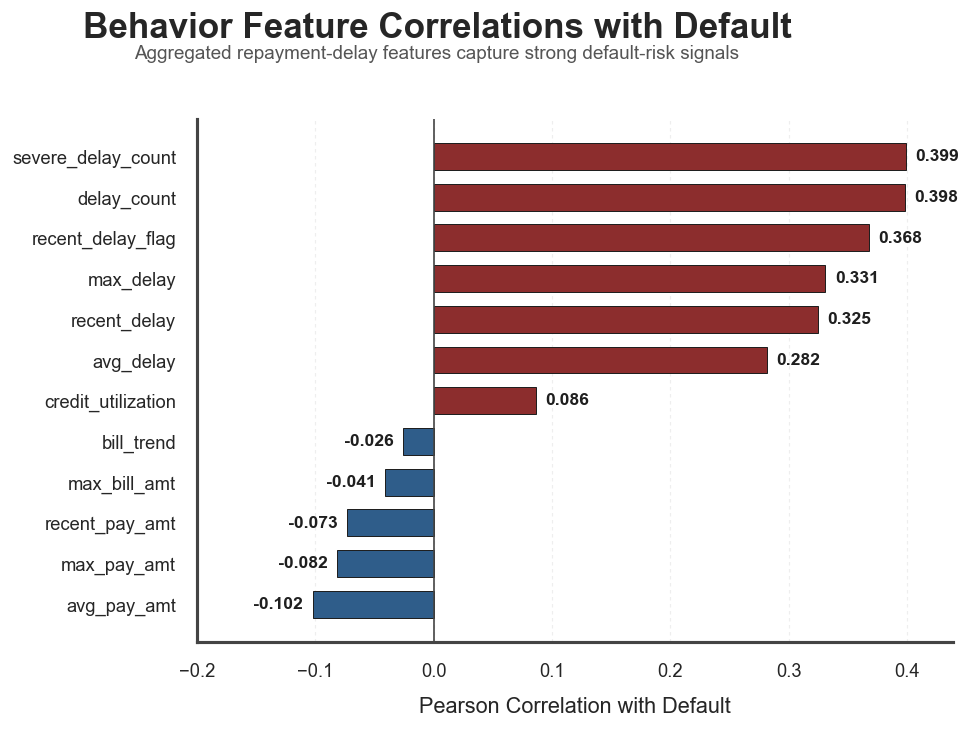

In [65]:
# Cell 12: Repayment-behavior feature engineering and correlation analysis
# This cell creates interpretable behavior features for later modeling.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="white", context="talk")

# =========================================================
# 1. Create behavior features
# =========================================================

df_behavior = df_eda.copy()

# -----------------------------
# Repayment delay behavior
# -----------------------------

# Count how many months had delayed repayment
df_behavior["delay_count"] = (df_behavior[pay_status_cols] > 0).sum(axis=1)

# Count severe delay months: repayment status >= 2
df_behavior["severe_delay_count"] = (df_behavior[pay_status_cols] >= 2).sum(axis=1)

# Maximum delay level in six repayment records
df_behavior["max_delay"] = df_behavior[pay_status_cols].max(axis=1)

# Average repayment status
df_behavior["avg_delay"] = df_behavior[pay_status_cols].mean(axis=1)

# Recent repayment status
df_behavior["recent_delay"] = df_behavior["PAY_0"]

# Whether the most recent record shows delayed payment
df_behavior["recent_delay_flag"] = (df_behavior["PAY_0"] > 0).astype(int)


# -----------------------------
# Bill amount behavior
# -----------------------------

df_behavior["avg_bill_amt"] = df_behavior[bill_cols].mean(axis=1)
df_behavior["max_bill_amt"] = df_behavior[bill_cols].max(axis=1)
df_behavior["min_bill_amt"] = df_behavior[bill_cols].min(axis=1)

# Recent bill amount
df_behavior["recent_bill_amt"] = df_behavior["BILL_AMT1"]

# Bill trend: recent bill minus oldest bill
df_behavior["bill_trend"] = df_behavior["BILL_AMT1"] - df_behavior["BILL_AMT6"]

# Credit utilization based on recent bill
df_behavior["credit_utilization"] = df_behavior["BILL_AMT1"] / (df_behavior["LIMIT_BAL"].replace(0, np.nan))


# -----------------------------
# Payment amount behavior
# -----------------------------

df_behavior["avg_pay_amt"] = df_behavior[pay_amt_cols].mean(axis=1)
df_behavior["max_pay_amt"] = df_behavior[pay_amt_cols].max(axis=1)
df_behavior["min_pay_amt"] = df_behavior[pay_amt_cols].min(axis=1)

# Recent payment amount
df_behavior["recent_pay_amt"] = df_behavior["PAY_AMT1"]

# Payment trend: recent payment minus oldest payment
df_behavior["pay_trend"] = df_behavior["PAY_AMT1"] - df_behavior["PAY_AMT6"]


# -----------------------------
# Payment-to-bill ratio behavior
# -----------------------------

# Recent payment-to-bill ratio:
# PAY_AMT1 corresponds to payment made toward previous bill record.
df_behavior["recent_pay_bill_ratio"] = (
    df_behavior["PAY_AMT1"] / (df_behavior["BILL_AMT2"].abs() + 1)
)

# Total payment-to-total-bill ratio across six periods
df_behavior["total_pay_bill_ratio"] = (
    df_behavior[pay_amt_cols].sum(axis=1) / (df_behavior[bill_cols].abs().sum(axis=1) + 1)
)

# Replace infinite values if any
df_behavior = df_behavior.replace([np.inf, -np.inf], np.nan)


# =========================================================
# 2. Behavior feature list
# =========================================================

behavior_cols = [
    "delay_count",
    "severe_delay_count",
    "max_delay",
    "avg_delay",
    "recent_delay",
    "recent_delay_flag",
    "avg_bill_amt",
    "max_bill_amt",
    "recent_bill_amt",
    "bill_trend",
    "credit_utilization",
    "avg_pay_amt",
    "max_pay_amt",
    "recent_pay_amt",
    "pay_trend",
    "recent_pay_bill_ratio",
    "total_pay_bill_ratio"
]

print("Number of behavior features created:", len(behavior_cols))
print("Behavior features:")
print(behavior_cols)


# =========================================================
# 3. Summary statistics
# =========================================================

behavior_summary = df_behavior[behavior_cols + [target]].describe().T

display(behavior_summary)

behavior_summary.to_csv(
    OUTPUT_DIR / "behavior_features_summary.csv"
)


# =========================================================
# 4. Mean / median comparison by default status
# =========================================================

behavior_group_summary = (
    df_behavior
    .groupby(target)[behavior_cols]
    .agg(["mean", "median"])
)

display(behavior_group_summary)

behavior_group_summary.to_csv(
    OUTPUT_DIR / "behavior_features_by_default_summary.csv"
)


# =========================================================
# 5. Correlation with default
# =========================================================

behavior_corr = (
    df_behavior[behavior_cols + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda x: abs(x), ascending=False)
)

behavior_corr_df = behavior_corr.to_frame("Correlation with Default")

display(behavior_corr_df)

behavior_corr_df.to_csv(
    OUTPUT_DIR / "behavior_features_target_correlation.csv"
)


# =========================================================
# 6. Publication-style correlation plot
# =========================================================

top_n = 12
top_behavior_corr = behavior_corr.head(top_n).sort_values()

fig, ax = plt.subplots(figsize=(10, 6.4), facecolor="white")

colors = [
    "#8C2D2D" if value > 0 else "#2F5D8A"
    for value in top_behavior_corr.values
]

bars = ax.barh(
    top_behavior_corr.index,
    top_behavior_corr.values,
    color=colors,
    edgecolor="#1F1F1F",
    linewidth=0.6,
    height=0.66
)

# Better x limits
min_x = min(top_behavior_corr.min() - 0.04, -0.20)
max_x = max(top_behavior_corr.max() + 0.04, 0.35)
ax.set_xlim(min_x, max_x)

# Reference line
ax.axvline(
    0,
    color="#444444",
    linewidth=1.0
)

# Value labels
for bar, value in zip(bars, top_behavior_corr.values):
    y = bar.get_y() + bar.get_height() / 2
    
    if value >= 0:
        label_x = value + 0.008
        ha = "left"
    else:
        label_x = value - 0.008
        ha = "right"
    
    ax.text(
        label_x,
        y,
        f"{value:.3f}",
        va="center",
        ha=ha,
        fontsize=10.5,
        fontweight="bold",
        color="#1F1F1F"
    )

fig.suptitle(
    "Behavior Feature Correlations with Default",
    fontsize=21,
    fontweight="bold",
    y=0.96
)

fig.text(
    0.5,
    0.905,
    "Aggregated repayment-delay features capture strong default-risk signals",
    ha="center",
    va="center",
    fontsize=11.3,
    color="#555555"
)

ax.set_xlabel("Pearson Correlation with Default", fontsize=13, labelpad=10)
ax.set_ylabel("")

ax.xaxis.grid(True, linestyle=(0, (3, 3)), linewidth=0.7, alpha=0.32)
ax.yaxis.grid(False)

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")

plt.subplots_adjust(
    top=0.82,
    bottom=0.14,
    left=0.30,
    right=0.93
)

path = FIG_DIR / "10_behavior_feature_correlations_with_default.png"
fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved figure: {path}")

plt.show()

,delay_count,count,Default Rate (%)
0,0,19931,11.710401
1,1,4426,29.823769
2,2,1899,38.757241
3,3,1154,50.866551
4,4,951,57.308097
5,5,298,57.382550
6,6,1341,70.320656


,severe_delay_count,count,Default Rate (%)
0,0,21620,12.747456
1,1,3494,32.226674
2,2,1567,43.395022
3,3,1073,54.799627
4,4,711,58.931083
5,5,597,57.118928
6,6,938,77.398721


Saved figure: outputs\eda_figures\11_default_rate_by_delay_count_features.png


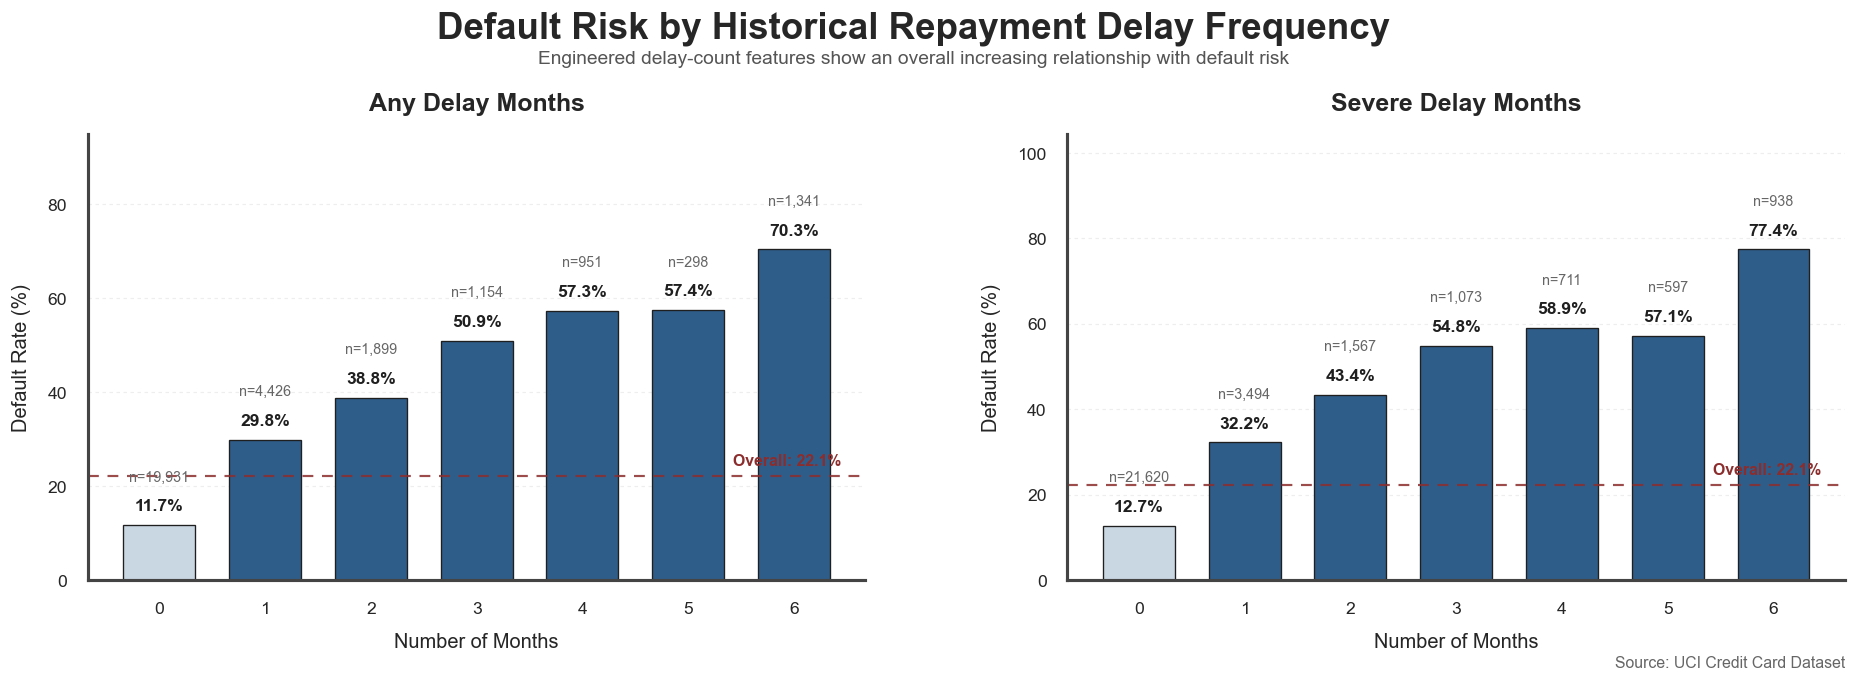

In [69]:
# Cell 13: Delay-count features and default risk
# Publication-style validation plot for engineered repayment behavior features

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="white", context="talk")

# =========================================================
# 1. Safety check
# =========================================================

required_cols = ["delay_count", "severe_delay_count", target]

for col in required_cols:
    if col not in df_behavior.columns:
        raise ValueError(
            f"{col} not found in df_behavior. Please run Cell 12 first."
        )


# =========================================================
# 2. Prepare default-rate tables
# =========================================================

def make_default_rate_table(data, feature):
    summary = (
        data
        .groupby(feature)[target]
        .agg(["count", "mean"])
        .reset_index()
    )
    
    summary["Default Rate (%)"] = summary["mean"] * 100
    summary = summary.drop(columns=["mean"])
    
    return summary


delay_count_rate = make_default_rate_table(df_behavior, "delay_count")
severe_delay_count_rate = make_default_rate_table(df_behavior, "severe_delay_count")

display(delay_count_rate)
display(severe_delay_count_rate)

delay_count_rate.to_csv(
    OUTPUT_DIR / "default_rate_by_delay_count.csv",
    index=False
)

severe_delay_count_rate.to_csv(
    OUTPUT_DIR / "default_rate_by_severe_delay_count.csv",
    index=False
)


# =========================================================
# 3. Plot helper
# =========================================================

def plot_delay_rate_panel(ax, data, x_col, title):
    base_color = "#C9D7E3"
    highlight_color = "#2F5D8A"
    
    # Use darker colors as delay count increases
    max_x = data[x_col].max()
    colors = [
        base_color if x == 0 else highlight_color
        for x in data[x_col]
    ]
    
    bars = ax.bar(
        data[x_col].astype(str),
        data["Default Rate (%)"],
        color=colors,
        width=0.68,
        edgecolor="#1F1F1F",
        linewidth=0.8
    )
    
    ymax = data["Default Rate (%)"].max()
    ax.set_ylim(0, ymax * 1.35)
    
    # Value labels and sample sizes
    for bar, rate, count in zip(
        bars,
        data["Default Rate (%)"],
        data["count"]
    ):
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        
        ax.text(
            x,
            y + ymax * 0.035,
            f"{rate:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10.5,
            fontweight="bold",
            color="#1F1F1F"
        )
        
        ax.text(
            x,
            y + ymax * 0.125,
            f"n={count:,}",
            ha="center",
            va="bottom",
            fontsize=8.6,
            color="#666666"
        )
    
    # Overall default rate reference line
    overall_default_rate = df_behavior[target].mean() * 100
    
    ax.axhline(
        overall_default_rate,
        color="#8C2D2D",
        linestyle=(0, (5, 4)),
        linewidth=1.3,
        alpha=0.85
    )
    
    ax.text(
        len(data) - 0.55,
        overall_default_rate + ymax * 0.025,
        f"Overall: {overall_default_rate:.1f}%",
        ha="right",
        va="bottom",
        fontsize=9.5,
        color="#8C2D2D",
        fontweight="bold"
    )
    
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14)
    ax.set_xlabel("Number of Months", fontsize=12, labelpad=10)
    ax.set_ylabel("Default Rate (%)", fontsize=12, labelpad=10)
    
    ax.yaxis.grid(True, linestyle=(0, (3, 3)), linewidth=0.7, alpha=0.32)
    ax.xaxis.grid(False)
    
    ax.tick_params(axis="x", labelsize=10.5)
    ax.tick_params(axis="y", labelsize=10.5)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#444444")
    ax.spines["bottom"].set_color("#444444")


# =========================================================
# 4. Create figure
# =========================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    facecolor="white"
)

fig.suptitle(
    "Default Risk by Historical Repayment Delay Frequency",
    fontsize=22,
    fontweight="bold",
    y=0.95
)

fig.text(
    0.5,
    0.885,
    "Engineered delay-count features show an overall increasing relationship with default risk",
    ha="center",
    va="center",
    fontsize=11.5,
    color="#555555"
)

plot_delay_rate_panel(
    axes[0],
    delay_count_rate,
    "delay_count",
    "Any Delay Months"
)

plot_delay_rate_panel(
    axes[1],
    severe_delay_count_rate,
    "severe_delay_count",
    "Severe Delay Months"
)

fig.text(
    0.985,
    0.035,
    "Source: UCI Credit Card Dataset",
    ha="right",
    va="bottom",
    fontsize=9.5,
    color="#666666"
)

plt.subplots_adjust(
    top=0.78,
    bottom=0.16,
    left=0.07,
    right=0.985,
    wspace=0.26
)

path = FIG_DIR / "11_default_rate_by_delay_count_features.png"
fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved figure: {path}")

plt.show()

In [73]:
# Cell 14: Generate final EDA summary, key findings, and report draft

from pathlib import Path
import pandas as pd
import numpy as np

# =========================================================
# 1. Basic dataset summary
# =========================================================

n_rows = df.shape[0]
n_cols = df.shape[1]
n_missing = int(df.isnull().sum().sum())
n_duplicates = int(df.duplicated().sum())

default_count = int(df_eda[target].sum())
non_default_count = int((df_eda[target] == 0).sum())

default_rate = df_eda[target].mean() * 100
non_default_rate = 100 - default_rate

# Main credit limit medians
credit_limit_median = (
    df_eda
    .assign(DEFAULT_STATUS=df_eda[target].map({0: "Non-default", 1: "Default"}))
    .groupby("DEFAULT_STATUS")["LIMIT_BAL"]
    .median()
)

non_default_limit_median = credit_limit_median.get("Non-default", np.nan)
default_limit_median = credit_limit_median.get("Default", np.nan)

# PAY_0 grouped result
if "pay0_group_rate" in globals():
    pay0_summary = pay0_group_rate.copy()
else:
    pay0_summary = pd.DataFrame()

# Delay-count result
if "delay_count_rate" in globals():
    delay_summary = delay_count_rate.copy()
else:
    delay_summary = pd.DataFrame()

if "severe_delay_count_rate" in globals():
    severe_delay_summary = severe_delay_count_rate.copy()
else:
    severe_delay_summary = pd.DataFrame()

# Behavior correlation result
if "behavior_corr_df" in globals():
    top_behavior = behavior_corr_df.head(8).copy()
else:
    top_behavior = pd.DataFrame()

# Original feature correlation result
if "target_corr_df" in globals():
    top_original_corr = target_corr_df.head(8).copy()
else:
    top_original_corr = pd.DataFrame()


# =========================================================
# 2. Save final numeric summary table
# =========================================================

eda_summary_final = pd.DataFrame({
    "Item": [
        "Number of observations",
        "Number of original columns",
        "Number of predictive features",
        "Missing values",
        "Duplicated rows",
        "Non-default clients",
        "Default clients",
        "Non-default rate",
        "Default rate",
        "Median credit limit: non-default",
        "Median credit limit: default"
    ],
    "Value": [
        f"{n_rows:,}",
        f"{n_cols}",
        f"{n_cols - 2}",
        f"{n_missing}",
        f"{n_duplicates}",
        f"{non_default_count:,}",
        f"{default_count:,}",
        f"{non_default_rate:.1f}%",
        f"{default_rate:.1f}%",
        f"{non_default_limit_median:,.0f}",
        f"{default_limit_median:,.0f}"
    ]
})

display(eda_summary_final)

eda_summary_final.to_csv(
    OUTPUT_DIR / "eda_summary_final.csv",
    index=False
)


# =========================================================
# 3. Recommended figure list
# =========================================================

recommended_figures = pd.DataFrame({
    "Figure": [
        "01_target_distribution_refined.png",
        "04_age_credit_limit_by_default_refined.png",
        "05_default_rate_by_PAY_0_grouped_final.png",
        "06_grouped_repayment_status_default_rate_heatmap_final.png",
        "07_billing_payment_patterns_by_default_refined.png",
        "08_top_correlations_with_default_refined.png",
        "10_behavior_feature_correlations_with_default.png",
        "11_default_rate_by_delay_count_features.png"
    ],
    "Recommended Use": [
        "Report + PPT",
        "Report, optional PPT",
        "Report + PPT",
        "Report, optional PPT",
        "Report",
        "Report + PPT",
        "Report, optional PPT",
        "Report + PPT"
    ],
    "Purpose": [
        "Show class imbalance in the target variable",
        "Compare age and credit limit by default status",
        "Show strong association between recent repayment delay and default rate",
        "Summarize default risk across repayment history variables",
        "Compare billing and payment amount patterns",
        "Identify original features most correlated with default",
        "Show engineered behavior features are strongly associated with default",
        "Validate delay-count features with default-rate patterns"
    ]
})

display(recommended_figures)

recommended_figures.to_csv(
    OUTPUT_DIR / "recommended_eda_figures.csv",
    index=False
)


# =========================================================
# 4. Generate key findings text
# =========================================================

key_findings = f"""
Exploratory Data Analysis Key Findings

1. Dataset Overview
The dataset contains {n_rows:,} observations and {n_cols} original columns. After excluding ID and the target variable, there are {n_cols - 2} predictive features. No missing values and no duplicated rows were found.

2. Target Distribution
The target variable is moderately imbalanced. Non-default clients account for {non_default_rate:.1f}% of the dataset, while default clients account for {default_rate:.1f}%. Therefore, accuracy alone is not sufficient for model evaluation. Precision, recall, F1-score, ROC-AUC, PR-AUC and confusion matrix should also be considered.

3. Demographic and Credit Limit Patterns
Default clients tend to have lower credit limits than non-default clients. The median credit limit of non-default clients is {non_default_limit_median:,.0f}, while the median credit limit of default clients is {default_limit_median:,.0f}. Age distributions show limited separation between the two groups.

4. Repayment Status and Default Risk
Recent repayment status is strongly associated with default risk. Clients with no recent delay or special repayment status show a much lower default rate, while clients with delayed repayment status show substantially higher default rates.

5. Repayment History
The grouped repayment-status heatmap shows that delayed repayment status consistently corresponds to higher default risk across historical repayment variables. This suggests that repayment behavior is one of the most important signals for default prediction.

6. Billing and Payment Behavior
Default clients show consistently lower median payment amounts across historical periods. This suggests that payment amount behavior can provide useful information for predicting default.

7. Correlation Analysis
Original repayment status variables, especially recent repayment status variables, show the strongest positive correlations with default. LIMIT_BAL and payment amount variables show negative correlations with default.

8. Engineered Behavior Features
Based on EDA, several repayment-behavior features were created, including delay_count, severe_delay_count, max_delay, avg_delay, recent_delay_flag, credit_utilization and payment-to-bill ratios. Among these, severe_delay_count and delay_count show particularly strong positive correlations with default, supporting their use in the modeling stage.

Overall, the EDA suggests that this project should not be treated as a simple accuracy-oriented binary classification problem. Instead, it should focus on risk-sensitive evaluation, repayment-behavior feature engineering, class imbalance, and model interpretability.
"""

print(key_findings)

with open(OUTPUT_DIR / "eda_key_findings.txt", "w", encoding="utf-8") as f:
    f.write(key_findings)


# =========================================================
# 5. Generate report-style markdown draft
# =========================================================

eda_report_draft = f"""
## Dataset, Features and Exploratory Data Analysis

## Dataset, Features and Exploratory Data Analysis

## Dataset, Features and Exploratory Data Analysis

The dataset used in this project contains 30,000 credit card client records with 23 predictive features after removing the ID column and the target variable. The prediction target is whether a client defaults on payment in the following month. No missing values or duplicated records were found. However, several categorical variables contain non-standard encoded values, such as unknown education and marriage categories, which require simple recoding before model training.

The target variable shows a moderate class imbalance. Non-default clients account for 77.9% of the dataset, while default clients account for 22.1%. This imbalance indicates that accuracy alone may not provide a reliable evaluation of model performance. A naive classifier biased toward the majority class could still achieve a relatively high accuracy while failing to detect risky clients. Therefore, later experiments should include precision, recall, F1-score, ROC-AUC, PR-AUC and confusion matrix.

The demographic analysis shows that default rates vary across demographic groups. However, demographic variables should be interpreted cautiously because they may involve fairness and ethical concerns. In contrast, credit limit shows a clearer relationship with default status. The median credit limit of non-default clients is 150,000, while the median credit limit of default clients is 90,000, suggesting that lower credit limits are associated with higher default risk.

Repayment status variables provide the strongest signals in the EDA. The recent repayment status variable PAY_0 shows a clear relationship with default risk. Clients without recent repayment delay have a much lower default rate, while clients with delayed repayment status have substantially higher default rates. The grouped repayment-status heatmap further confirms that delayed repayment status consistently corresponds to higher observed default rates across historical repayment records.

Billing and payment amount variables also show useful patterns. Default clients tend to have lower median payment amounts across historical periods, suggesting that payment behavior contains additional information for default prediction. This motivates the construction of repayment-behavior features in the later modeling stage.

Based on these observations, several engineered behavior features were created, including delay_count, severe_delay_count, max_delay, avg_delay, recent_delay_flag, credit_utilization and payment-to-bill ratios. Correlation analysis shows that aggregated repayment-delay features, especially severe_delay_count and delay_count, have strong positive associations with default. This supports using engineered repayment-behavior features to improve model interpretability and provide additional predictive information.

Overall, the EDA suggests that credit card default prediction should not be treated as a simple accuracy-oriented binary classification task. Instead, the later modeling stage should focus on imbalance-aware evaluation, risk-sensitive metrics, threshold optimization, and interpretable repayment-behavior features.
"""

print("\n" + "=" * 80)
print("Report-style EDA draft:")
print("=" * 80)
print(eda_report_draft)

with open(OUTPUT_DIR / "eda_report_draft.md", "w", encoding="utf-8") as f:
    f.write(eda_report_draft)


# =========================================================
# 6. Final output message
# =========================================================

print("\nEDA summary files saved:")
print("-", OUTPUT_DIR / "eda_summary_final.csv")
print("-", OUTPUT_DIR / "recommended_eda_figures.csv")
print("-", OUTPUT_DIR / "eda_key_findings.txt")
print("-", OUTPUT_DIR / "eda_report_draft.md")

,Item,Value
0,Number of observations,"30,000"
1,Number of original columns,25
2,Number of predictive features,23
3,Missing values,0
4,Duplicated rows,0
5,Non-default clients,"23,364"
6,Default clients,"6,636"
7,Non-default rate,77.9%
8,Default rate,22.1%
9,Median credit limit: non-default,"150,000"


,Figure,Recommended Use,Purpose
0,01_target_distribution_refined.png,Report + PPT,Show class imbalance in the target variable
1,04_age_credit_limit_by_default_refined.png,"Report, optional PPT",Compare age and credit limit by default status
2,05_default_rate_by_PAY_0_grouped_final.png,Report + PPT,Show strong association between recent repayme...
3,06_grouped_repayment_status_default_rate_heatm...,"Report, optional PPT",Summarize default risk across repayment histor...
4,07_billing_payment_patterns_by_default_refined...,Report,Compare billing and payment amount patterns
5,08_top_correlations_with_default_refined.png,Report + PPT,Identify original features most correlated wit...
6,10_behavior_feature_correlations_with_default.png,"Report, optional PPT",Show engineered behavior features are strongly...
7,11_default_rate_by_delay_count_features.png,Report + PPT,Validate delay-count features with default-rat...



Exploratory Data Analysis Key Findings

1. Dataset Overview
The dataset contains 30,000 observations and 25 original columns. After excluding ID and the target variable, there are 23 predictive features. No missing values and no duplicated rows were found.

2. Target Distribution
The target variable is moderately imbalanced. Non-default clients account for 77.9% of the dataset, while default clients account for 22.1%. Therefore, accuracy alone is not sufficient for model evaluation. Precision, recall, F1-score, ROC-AUC, PR-AUC and confusion matrix should also be considered.

3. Demographic and Credit Limit Patterns
Default clients tend to have lower credit limits than non-default clients. The median credit limit of non-default clients is 150,000, while the median credit limit of default clients is 90,000. Age distributions show limited separation between the two groups.

4. Repayment Status and Default Risk
Recent repayment status is strongly associated with default risk. Clients with